In [1]:
import pyomo.environ as pyo
import idaes
import math
import pandas as pd
import numpy as np
from scipy import stats
import pyomo.dae as dae
import matplotlib.pyplot as plt
from pyomo.contrib.parmest.experiment import Experiment
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.contrib.parmest import parmest
from scipy.stats import chi2
import matplotlib.lines as mlines
from matplotlib.patches import Patch

# Create the class and functions to be used in this notebook

In [2]:
class BatchReactorExperiment(Experiment):
    """Creates and labels the Pyomo model of the batch reactor
    
    Parameters
    ----------
    data: Pandas.DataFrame or .csv file,
        Data containing the sample time and measured values of mass fractions 
    XA0: float,
        Initial mass fraction of species A
    temp_control: int, float, list, or dict,
        Constant or piecewise-linear profile of the reaction temperature (in R)
    const_temp: Boolean,
        Species if the batch reactor is a constant or variable temperature system
    doe_solve: Boolean,
        Species if the batch reactor model is being used for optimal experimental design
    prior_est: Boolean,
        Specifies if prior information is to be included
    expert_profile: Boolean,
        Specifies if we are using an expert intuition for the temperature profile

    Returns
    -------
    m: annotated Pyomo model of the batch reactor
    """

    def __init__(self, XA0, temp_control, const_temp, data=None, doe_solve=False, 
                 prior_est=False, expert_profile=False,):

        self.data = data
        self.XA0 = XA0
        self.temp_control = temp_control
        self.const_temp = const_temp
        self.doe_solve = doe_solve
        self.prior_est = prior_est
        self.expert_profile = expert_profile
        self.model = None

    def get_labeled_model(self):
        self.create_model()
        self.label_model()

        return self.model

    def create_model(self):
        if self.const_temp and not self.doe_solve:
            self.model = reform_const_temp_reactor_model(self.XA0, self.temp_control)
        elif not self.const_temp and not self.doe_solve:
            if self.prior_est:
                self.model = reform_optimal_exp_design_model(self.XA0, self.temp_control, 
                                                             self.expert_profile)
            else:
                self.model = reform_var_temp_reactor_model(self.XA0, self.temp_control)
        elif not self.const_temp and self.doe_solve:
            self.model = reform_var_temp_doe_model(self.XA0, self.temp_control)

        return self.model

    def label_model(self):

        m = self.model

        if self.doe_solve:
            # label the experimental decision variables
            m.experiment_inputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
            m.experiment_inputs.update(
                (m.T_reparam[t], None) for t in m.t
            )

            # label the measured variables
            m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
            m.experiment_outputs.update(
                (m.XA[t], None) for t in m.t
            )
            m.experiment_outputs.update(
                (m.XB[t], None) for t in m.t
            )
            m.experiment_outputs.update(
                (m.XC[t], None) for t in m.t
            )
            m.experiment_outputs.update(
                (m.XP[t], None) for t in m.t
            )
            m.experiment_outputs.update(
                (m.XE[t], None) for t in m.t
            )
            m.experiment_outputs.update(
                (m.XG[t], None) for t in m.t
            )

            # add the measurement errors
            m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
            m.measurement_error.update(
                (m.XA[t], 0.01) for t in m.t
            )
            m.measurement_error.update(
                (m.XB[t], 0.001) for t in m.t
            )
            m.measurement_error.update(
                (m.XC[t], 0.001) for t in m.t
            )
            m.measurement_error.update(
                (m.XP[t], 0.01) for t in m.t
            )
            m.measurement_error.update(
                (m.XE[t], 0.01) for t in m.t
            )
            m.measurement_error.update(
                (m.XG[t], 0.01) for t in m.t
            )
        else:
            meas_time_points = self.data["Time (hr)"]
        
            # label the measured variables
            m.experiment_outputs = pyo.Suffix(direction=pyo.Suffix.LOCAL)
            m.experiment_outputs.update(
                (m.XA[t], self.data["XA"][ind]) for ind, t in enumerate(meas_time_points)
            )
            m.experiment_outputs.update(
                (m.XB[t], self.data["XB"][ind]) for ind, t in enumerate(meas_time_points)
            )
            m.experiment_outputs.update(
                (m.XC[t], self.data["XC"][ind]) for ind, t in enumerate(meas_time_points)
            )
            m.experiment_outputs.update(
                (m.XP[t], self.data["XP"][ind]) for ind, t in enumerate(meas_time_points)
            )
            m.experiment_outputs.update(
                (m.XE[t], self.data["XE"][ind]) for ind, t in enumerate(meas_time_points)
            )
            m.experiment_outputs.update(
                (m.XG[t], self.data["XG"][ind]) for ind, t in enumerate(meas_time_points)
            )
            
            # add the measurement errors
            m.measurement_error = pyo.Suffix(direction=pyo.Suffix.LOCAL)
            m.measurement_error.update(
                (m.XA[t], 0.01) for t in meas_time_points
            )
            m.measurement_error.update(
                (m.XB[t], 0.001) for t in meas_time_points
            )
            m.measurement_error.update(
                (m.XC[t], 0.001) for t in meas_time_points
            )
            m.measurement_error.update(
                (m.XP[t], 0.01) for t in meas_time_points
            )
            m.measurement_error.update(
                (m.XE[t], 0.01) for t in meas_time_points
            )
            m.measurement_error.update(
                (m.XG[t], 0.01) for t in meas_time_points
            )

        # label the unknown parameters
        m.unknown_parameters = pyo.Suffix(direction=pyo.Suffix.LOCAL)
        m.unknown_parameters.update(
            (k, pyo.value(k)) for k in [m.alpha_1, m.alpha_2, m.alpha_3, m.E1, m.E2, m.E3]
        )

        return m

In [3]:
def get_original_parameters(reform_params):
    """
    Calculates the original parameters from the reformulated parameters

    Parameters
    ----------
    reform_params: dict,
        Estimated values of the reformulated parameters
    
    Returns
    -------
    orig_params: dict, calculated values of the original parameters
    """
    
    # get the original a1, a2, and a3 parameters
    a1 = np.exp(reform_params['alpha_1'])
    a2 = np.exp(reform_params['alpha_2'])
    a3 = np.exp(reform_params['alpha_3'])

    # create a new dictionary for the original parameters
    orig_params = {"a1":a1, "a2":a2, "a3":a3, "E1": reform_params["E1"], "E2": reform_params["E2"], "E3": reform_params["E3"]}

    return orig_params

In [4]:
def get_original_covariance(reform_params, cov_reform):
    """
    Computes the covariance matrix of the original parameters

    Parameters
    ----------
    reform_params: dict,
        Estimated values of the reformulated parameters
    cov_reform: Pandas.DataFrame,
        Covariance matrix of the reformulated parameters    
    
    Returns
    -------
    cov_orig_df: Pandas.DataFrame, covariance matrix of the original parameters
    """

    # derivative of a1 w.r.t. all the parameters given that a1 = exp(alpha_1)
    da1_dalpha_1 = np.exp(reform_params['alpha_1'])
    da1_dalpha_2 = 0
    da1_dalpha_3 = 0
    da1_dE1 = 0
    da1_dE2 = 0
    da1_dE3 = 0
    da1_dbeta = [da1_dalpha_1, da1_dalpha_2, da1_dalpha_3, da1_dE1, da1_dE2, da1_dE3]
    
    # derivative of a2 w.r.t. all the parameters given that a2 = exp(alpha_2)
    da2_dalpha_1 = 0
    da2_dalpha_2 = np.exp(reform_params['alpha_2'])
    da2_dalpha_3 = 0
    da2_dE1 = 0
    da2_dE2 = 0
    da2_dE3 = 0
    da2_dbeta = [da2_dalpha_1, da2_dalpha_2, da2_dalpha_3, da2_dE1, da2_dE2, da2_dE3]
    
    # derivative of a3 w.r.t. all the parameters given that a3 = exp(alpha_3)
    da3_dalpha_1 = 0
    da3_dalpha_2 = 0
    da3_dalpha_3 = np.exp(reform_params['alpha_3'])
    da3_dE1 = 0
    da3_dE2 = 0
    da3_dE3 = 0
    da3_dbeta = [da3_dalpha_1, da3_dalpha_2, da3_dalpha_3, da3_dE1, da3_dE2, da3_dE3]

    # derivative of E1 w.r.t. all the parameters given that E1 = E1
    dE1_dalpha_1 = 0
    dE1_dalpha_2 = 0
    dE1_dalpha_3 = 0
    dE1_dE1 = 1
    dE1_dE2 = 0
    dE1_dE3 = 0
    dE1_dbeta = [dE1_dalpha_1, dE1_dalpha_2, dE1_dalpha_3, dE1_dE1, dE1_dE2, dE1_dE3]
    
    # derivative of E2 w.r.t. all the parameters given that E2 = E2
    dE2_dalpha_1 = 0
    dE2_dalpha_2 = 0
    dE2_dalpha_3 = 0
    dE2_dE1 = 0
    dE2_dE2 = 1
    dE2_dE3 = 0
    dE2_dbeta = [dE2_dalpha_1, dE2_dalpha_2, dE2_dalpha_3, dE2_dE1, dE2_dE2, dE2_dE3]
    
    # derivative of E3 w.r.t. all the parameters given that E3 = E3
    dE3_dalpha_1 = 0
    dE3_dalpha_2 = 0
    dE3_dalpha_3 = 0
    dE3_dE1 = 0
    dE3_dE2 = 0
    dE3_dE3 = 1
    dE3_dbeta = [dE3_dalpha_1, dE3_dalpha_2, dE3_dalpha_3, dE3_dE1, dE3_dE2, dE3_dE3]

    # Jacobian matrix
    dtheta_dbeta = np.zeros((6, 6))
    dtheta_dbeta[0, :] = da1_dbeta
    dtheta_dbeta[1, :] = da2_dbeta
    dtheta_dbeta[2, :] = da3_dbeta
    dtheta_dbeta[3, :] = dE1_dbeta
    dtheta_dbeta[4, :] = dE2_dbeta
    dtheta_dbeta[5, :] = dE3_dbeta

    # calculate the covariance matrix of the original parameters
    cov_orig = dtheta_dbeta @ cov_reform @ dtheta_dbeta.T
    cov_orig_df = pd.DataFrame(
                                cov_orig.to_numpy(),
                                index=["a1", "a2", "a3", "E1", "E2", "E3"],
                                columns=["a1", "a2", "a3", "E1", "E2", "E3"],)

    return cov_orig_df

In [5]:
def parameter_covariance_est(data, XA0, temp_control=None, 
                             const_temp=True, 
                             doe_solve=False, 
                             prior_est=False, theta_ref=None, prior_FIM=None, 
                             expert_profile=False,):
    """Estimates the parameters and covariance matrix of the batch reactor model from the data

    Parameters
    ----------
    data: Pandas.DataFrame or .csv file,
        Data containing the sample time and measured values of species mass fraction
    XA0: float,
        Initial mass fraction of species A
    temp_control: int, float, or dict,
        Constant or piecewise-linear profile of the reaction temperature (in R)
    const_temp: Boolean,
        Species if the batch reactor is a constant or variable temperature system
    doe_solve: Boolean,
        Species if the batch reactor model is being used for optimal experimental design
    prior_est: Boolean,
        Specifies if prior information is to be included
    theta_ref: dict,
        Prior estimates of the parameters
    prior_FIM: Pandas.DataFrame,
        Prior Fisher information matrix of the estimated parameters
    expert_profile: Boolean,
        Specifies if we are using an expert intuition for the temperature profile

    Returns
    -------
    theta_original: dict, estimated values of the model parameters
    cov_theta_df: Pandas.DataFrame, covariance matrix of the estimated model parameters
    """

    # create a list of the experiment class
    exp_list = [BatchReactorExperiment(data=data, XA0=XA0, temp_control=temp_control, 
                                       const_temp=const_temp, 
                                       doe_solve=doe_solve, 
                                       prior_est=prior_est, 
                                       expert_profile=expert_profile,)]

    # create the Estimator object
    if not prior_est:
        pest = parmest.Estimator(exp_list, obj_function="SSE_weighted", tee=True)
    else:
        pest = parmest.Estimator(exp_list, obj_function="SSE_weighted", tee=True,
                                regularization="L2", prior_FIM=prior_FIM, theta_ref=theta_ref)
    
    # estimate the reformulated parameters
    obj, theta_reform = pest.theta_est()
    print("The reformulated parameters are:", theta_reform)

    # get the original parameters
    theta_original = get_original_parameters(theta_reform)

    # compute the covariance matrix of the reformulated parameters
    try:
        cov_reform = pest.cov_est(method="finite_difference")
        print("Covariance matrix of reformulated parameters:\n", cov_reform)

        # get the Fisher information matrix
        prior_FIM_reform = np.linalg.inv(cov_reform)
        print("\nThe FIM of the reformulated model:\n", prior_FIM_reform)

        # get the covariance matrix of the original parameters
        cov_original = get_original_covariance(theta_reform, cov_reform)

        return obj, theta_original, cov_original
    except RuntimeError:
        return obj, theta_original, ["N/A"]
    

In [6]:
def ground_truth_data(measured_var):
    """Creates a Pandas dataframe for ground-truth simulation of mass fractions

    Parameters
    ----------
    measured_var: 2D numpy array or matrix,
        matrix containing ground-truth simulation of mass fractions

    Returns
    -------
    outputs: Pandas dataframe containing ground-truth simulation of mass fractions 
    """
    
    # name of experimental outputs
    output_names = ["XA", "XB", "XC", "XP", "XE", "XG"]
    
    # outputs dataframe
    outputs = pd.DataFrame(measured_var, columns=output_names)
    
    print("\nOutput variables:\n",outputs)

    return outputs


def generate_noisy_mass_fraction(
    ground_truth,
    species_cols,
    standard_dev,
    seed=10,
):
    """
    Adds Gaussian noise to the true values of the mass fractions

    Parameters
    ----------
    ground_truth: pandas.DataFrame,
        Dataframe containing the true values of the mass fractions
    species_cols: list
        List of species column names
    standard_dev: dict
        Dictionary mapping species names to standard deviations
    seed: int, optional
        Random seed for reproducibility

    Returns
    -------
    noisy_mass_frac: pandas.DataFrame,
        Dataframe containing noisy mass fractions measurements
    """

    random_nunber_gen = np.random.default_rng(seed)

    noisy_mass_frac = ground_truth.copy()

    # add a Gaussian noise
    for col in species_cols:
        # generate Gaussian noise
        noise = random_nunber_gen.normal(
            loc=0,
            scale=standard_dev[col],
            size=len(noisy_mass_frac)
        )

        # add noise to the ground truth values
        noisy_mass_frac[col] = noisy_mass_frac[col] + noise

    # enforce non-negative mass fractions
    noisy_mass_frac[species_cols] = noisy_mass_frac[species_cols].clip(lower=0)

    # get the sum of every row
    row_sums = noisy_mass_frac[species_cols].sum(axis=1)

    # divide every value in a row by its own row sum so they add to 1
    noisy_mass_frac[species_cols] = noisy_mass_frac[species_cols].div(
        row_sums,
        axis=0
    )

    return noisy_mass_frac


def synthetic_data_compiler(sample_time, mass_frac_data, csv_name):
    """Generates noisy measurement of mass fractions

    Parameters
    ----------
    sample_time:
        Timepoints (in hr) that samples were collected for mass fraction measurements
    mass_frac_data: pandas.DataFrame,
        Dataframe containing the mass fraction measurements 
    csv_name: str,
        File name for the csv

    Returns
    -------
    data: pandas.DataFrame containing the full generated data
    """
    # data columns
    column_names = ["Time (hr)", "XA", "XB", "XC", "XP", "XE", "XG"]

    # get the number of time samples
    n_samples = len(sample_time)
    
    # define a matrix that contains the sample time and mass fractions
    data_matrix = np.zeros((n_samples, 7))
    data_matrix[:, 0] = sample_time
    data_matrix[:, 1] = mass_frac_data["XA"]
    data_matrix[:, 2] = mass_frac_data["XB"]
    data_matrix[:, 3] = mass_frac_data["XC"]
    data_matrix[:, 4] = mass_frac_data["XP"]
    data_matrix[:, 5] = mass_frac_data["XE"]
    data_matrix[:, 6] = mass_frac_data["XG"]
    
    # number of data columns
    n_columns = len(column_names)
    
    # full data
    data = pd.DataFrame(data_matrix, columns=column_names)
    print("Generated data:\n",data)
    
    data.to_csv(f"{csv_name}.csv", index=False)

    return data
    

## True value of model parameters

In [7]:
true_params = {'a1': 5.98e9, 'a2': 2.6e12, 'a3': 9.63e15, 
               'E1': 120, 'E2': 150, 'E3': 200}

## High temperature constant batch reactor

In [8]:
def const_temp_reactor_model(XA0, temp, meas_sample_time, low_temp=False):
    """
    Creates a constant temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp: int or float,
        Constant reaction temperature in R
    meas_sample_time: list,
        Timepoints (in hr) to collect samples for mass fraction measurements
    low_temp: Boolean,
        Specifies if the constant reaction temperature is low or high

    Returns
    -------
    measured_variables: list containing the mass fraction of all species at the sample timepoints
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0.0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=(0, 1))
    model.T_reparam.fix(1/temp)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == pyo.log(m.a1) - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == pyo.log(m.a2) - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == pyo.log(m.a3) - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - XA0)
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    t_values = [t for t in model.t]
    print("Timepoints are:", t_values)
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_values = [1 / pyo.value(model.T_reparam) for t in model.t]

    # plot the temperature and mass fraction profiles
    fig, ax1 = plt.subplots(figsize=(6.5, 5))

    # set the primary axis: mass fraction
    ax1.plot(t_values, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    ax1.plot(t_values, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    ax1.plot(t_values, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    ax1.plot(t_values, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    ax1.plot(t_values, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    ax1.plot(t_values, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    ax1.set_xlabel('Time (hr)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Mass Fraction', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='x', labelsize=16, direction="in", top=True, right=True)
    ax1.tick_params(axis='y', labelsize=16, direction="in", top=True, right=True)

    # set the secondary axis: temperature
    ax2 = ax1.twinx()
    ax2.plot(t_values, temp_values, color='red', linewidth=3)
    ax2.set_ylabel('Temperature (R)', color='red', fontsize=16, fontweight='bold')
    ax2.set_ylim((5.77, 7.03))
    ax2.tick_params(axis='y', labelsize=16, labelcolor='red', direction="in", top=True, right=True)

    # add legend
    plt.grid()
    # ax1.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1.5, 0.5))
    plt.tight_layout()
    if low_temp:
        plt.savefig("const_low_temp_mass_profile.png")
    else:
        plt.savefig("const_high_temp_mass_profile.png")
    plt.show()

    # store the mass fraction of all species at the sample time
    measured_variables = []
    for sample_time in meas_sample_time:
        measured_variables.append([pyo.value(model.XA[sample_time]), pyo.value(model.XB[sample_time]), 
                                   pyo.value(model.XC[sample_time]), pyo.value(model.XP[sample_time]), 
                                   pyo.value(model.XE[sample_time]), pyo.value(model.XG[sample_time])])

    print("Mass fraction of species at the sample time:",measured_variables)
    return measured_variables

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

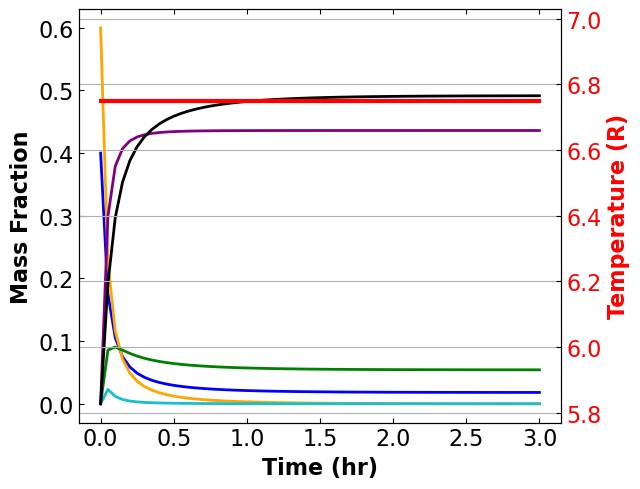

Mass fraction of species at the sample time: [[0.02943708587381165, 0.012262795363909696, 0.0008763946459984678, 0.0642238642166161, 0.43434858101980345, 0.45885127887986055], [0.019086341913254378, 0.001045778471770597, 6.391731908421214e-05, 0.05519942745576616, 0.43608112688296613, 0.48852340795715854], [0.0181015238584968, 5.248999203509859e-05, 3.1426426156195257e-06, 0.05420116291273197, 0.43609806773292353, 0.491543612861197]]

Output variables:
          XA        XB        XC        XP        XE        XG
0  0.029437  0.012263  0.000876  0.064224  0.434349  0.458851
1  0.019086  0.001046  0.000064  0.055199  0.436081  0.488523
2  0.018102  0.000052  0.000003  0.054201  0.436098  0.491544


In [9]:
# define the constant temperature and sample time for mass fraction measurements
high_const_temp = 6.75
sample_time = [0.5, 1.5, 3]

# get the ground-truth simulation of the mass fractions
measured_var_high_temp = const_temp_reactor_model(0.4, high_const_temp, sample_time)

# make a dataframe of the measured variables
outputs_df_high_temp = ground_truth_data(measured_var_high_temp)

### Add Gaussian noise to the ground-truth simulations

In [10]:
# define the species
species = ["XA", "XB", "XC", "XP", "XE", "XG"]

# define the measurement error of the mass fraction measurements
std_dict = {
    "XA": 0.01,
    "XB": 0.001,
    "XC": 0.001,
    "XP": 0.01,
    "XE": 0.01,
    "XG": 0.01,
}

# generate the noisy mass fraction measurements
noisy_mass_frac_high = generate_noisy_mass_fraction(
    outputs_df_high_temp,
    species_cols=species,
    standard_dev=std_dict,
)

### Compile the generated data into a csv file

In [11]:
data_high_temp = synthetic_data_compiler(sample_time, noisy_mass_frac_high, 
                                         "batch_reactor_const_temp")

Generated data:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.018958  0.012907  0.001771  0.061513  0.443878  0.460974
1        1.5  0.011976  0.000807  0.000933  0.048212  0.440700  0.497373
2        3.0  0.010752  0.000187  0.000500  0.048153  0.445815  0.494593


### Reformulate the batch reactor model for parameter estimation

In [12]:
def reform_const_temp_reactor_model(XA0, temp):
    """
    Reformulates the constant temperature batch reactor model for parameter estimation

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp: int or float,
        Constant reaction temperature in R

    Returns
    -------
    model: Pyomo model of the batch reactor
    
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.alpha_1 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_2 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_3 = pyo.Var(bounds=(0, None), initialize=10)
    model.E1 = pyo.Var(bounds=(0, None), initialize=50)
    model.E2 = pyo.Var(bounds=(0, None), initialize=50)
    model.E3 = pyo.Var(bounds=(0, None), initialize=50)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=(0, 1))
    model.T_reparam.fix(1/temp)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == model.alpha_1 - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == model.alpha_2 - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == model.alpha_3 - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA_init = pyo.Constraint(expr=model.XA[t0] == XA0)
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC_init = pyo.Constraint(expr=model.XC[t0] == 0.0)
    model.XE_init = pyo.Constraint(expr=model.XE[t0] == 0.0)
    model.XG_init = pyo.Constraint(expr=model.XG[t0] == 0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)
    
    return model

In [13]:
obj_high, estimated_params_high, cov_matrix_high = parameter_covariance_est(data_high_temp, XA0=0.4, 
                                                                            temp_control=high_const_temp,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

C:\Users\lilon\AppData\Local\Temp\ipykernel_9200\1011479802.py:16: RuntimeWarning: overflow encountered in exp
  a1 = np.exp(reform_params['alpha_1'])
C:\Users\lilon\AppData\Local\Temp\ipykernel_9200\1011479802.py:17: RuntimeWarning: overflow encountered in exp
  a2 = np.exp(reform_params['alpha_2'])
C:\Users\lilon\AppData\Local\Temp\ipykernel_9200\1011479802.py:18: RuntimeWarning: overflow encountered in exp
  a3 = np.exp(reform_params['alpha_3'])


Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [14]:
print("Estimates of the original parameters:\n",estimated_params_high)
print("\nCovariance matrix of the original parameters:\n",cov_matrix_high)

Estimates of the original parameters:
 {'a1': np.float64(inf), 'a2': np.float64(inf), 'a3': np.float64(inf), 'E1': 174177.62484335795, 'E2': 174174.36143907165, 'E3': 174171.56207073235}

Covariance matrix of the original parameters:
 ['N/A']


## Optimal reaction temperature to maximize main product P

In [15]:
def optimize_reactor_const_temp(XA0):
    """
    Creates a constant temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A

    Returns
    -------
    measured_variables: float or int, temperature that maximizes main product P formation
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variable
    model.T_reparam = pyo.Var(bounds=[1/6.8, 1/5.8], initialize=1/6)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, bounds=(0, None))
    model.k = pyo.Var(reaction_number, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i):
        if i == 1:
            return m.k_reparam[i] == pyo.log(m.a1) - m.E1 * m.T_reparam
        elif i == 2:
            return m.k_reparam[i] == pyo.log(m.a2) - m.E2 * m.T_reparam
        else:
            return m.k_reparam[i] == pyo.log(m.a3) - m.E3 * m.T_reparam
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i):
        return m.k[i] == pyo.exp(m.k_reparam[i])
    
    model.k_eq = pyo.Constraint(
        reaction_number, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1] * m.XA[t] * m.XB[t] + m.k[2] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1] * m.XA[t] * m.XB[t] - 2 * m.k[2] * m.XB[t] * m.XC[t] - m.k[3] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - pyo.value(model.XA[t0]))
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # objective function
    model.obj = pyo.Objective(expr=model.XP[3], sense=pyo.maximize)
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    return 1 / pyo.value(model.T_reparam)

In [16]:
# get the optimal reaction temperature to maximize the main product
optimal_const_temp = optimize_reactor_const_temp(0.4)

print("The optimal constant temperature is:", optimal_const_temp)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

## Constant low (optimal) temperature batch reactor

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

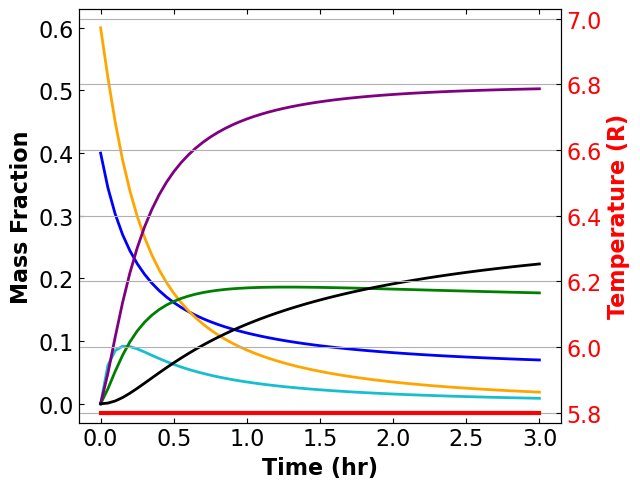

Mass fraction of species at the sample time: [[0.16163863212290347, 0.17649914735170996, 0.0628624380276193, 0.16334882065201314, 0.37027896955009576, 0.06537199229505881], [0.09268207815481715, 0.05173636753399112, 0.022318695977304116, 0.1857328473558461, 0.48189142125626144, 0.16563858972265555], [0.06991210261990598, 0.018568852705220212, 0.00872868852515366, 0.17696294668594761, 0.5026864998408634, 0.2231409096236843]]

Output variables:
          XA        XB        XC        XP        XE        XG
0  0.161639  0.176499  0.062862  0.163349  0.370279  0.065372
1  0.092682  0.051736  0.022319  0.185733  0.481891  0.165639
2  0.069912  0.018569  0.008729  0.176963  0.502686  0.223141


In [17]:
# get the ground-truth simulation of the mass fractions
measured_var_low_temp = const_temp_reactor_model(0.4, optimal_const_temp, sample_time, 
                                                 low_temp=True)

# make a dataframe of the measured variables
outputs_df_low_temp = ground_truth_data(measured_var_low_temp)

In [18]:
# generate the noisy mass fraction measurements
noisy_mass_frac_low = generate_noisy_mass_fraction(
    outputs_df_low_temp,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
data_low_temp = synthetic_data_compiler(sample_time, noisy_mass_frac_low, 
                                        "batch_reactor_const_temp_low")

Generated data:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.155138  0.182086  0.065623  0.163621  0.377880  0.055653
1        1.5  0.086439  0.052095  0.023450  0.180283  0.487050  0.170684
2        3.0  0.064925  0.019548  0.009623  0.176511  0.515439  0.213953


In [19]:
# estimate the parameters
obj_low, estimated_params_low, cov_matrix_low = parameter_covariance_est(data_low_temp, XA0=0.4, 
                                                                         temp_control=optimal_const_temp,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

C:\Users\lilon\AppData\Local\Temp\ipykernel_9200\1011479802.py:16: RuntimeWarning: overflow encountered in exp
  a1 = np.exp(reform_params['alpha_1'])
C:\Users\lilon\AppData\Local\Temp\ipykernel_9200\1011479802.py:17: RuntimeWarning: overflow encountered in exp
  a2 = np.exp(reform_params['alpha_2'])
C:\Users\lilon\AppData\Local\Temp\ipykernel_9200\1011479802.py:18: RuntimeWarning: overflow encountered in exp
  a3 = np.exp(reform_params['alpha_3'])


   1  0.0000000e+00 1.35e+00 1.18e+00  -1.0 1.90e+00    -  1.67e-02 1.17e-02f  1
   2  0.0000000e+00 1.35e+00 2.43e+01  -1.0 1.39e+00    -  1.08e-02 1.60e-03f  1
   3  0.0000000e+00 5.93e-01 2.16e+02  -1.0 1.45e+00    -  2.14e-02 5.61e-01f  1
   4  0.0000000e+00 3.02e-01 6.80e+01  -1.0 1.06e+00    -  9.53e-02 4.91e-01f  1
   5  0.0000000e+00 6.70e+01 7.09e+02  -1.0 6.52e+00    -  3.24e-02 7.78e-01f  1
   6  0.0000000e+00 2.33e+01 2.43e+02  -1.0 9.54e-01   2.0 4.08e-01 9.90e-01h  1
   7  0.0000000e+00 4.30e+00 7.97e+03  -1.0 6.12e+00    -  6.02e-01 9.92e-01h  1
   8  0.0000000e+00 4.96e-01 5.05e+02  -1.0 2.55e-01   1.5 1.00e+00 1.00e+00h  1
   9  0.0000000e+00 1.22e-01 1.05e+06  -1.0 5.18e+01    -  8.68e-01 1.00e+00f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10  0.0000000e+00 2.93e+00 5.45e+05  -1.0 3.98e+02    -  4.81e-01 1.00e+00f  1
  11  0.0000000e+00 1.68e-02 2.38e+05  -1.0 7.61e+02    -  5.63e-01 1.00e+00h  1
  12  0.0000000e+00 1.89e-03

In [20]:
print("Estimates of the original parameters:\n",estimated_params_low)
print("\nCovariance matrix of the original parameters:\n",cov_matrix_low)

Estimates of the original parameters:
 {'a1': np.float64(inf), 'a2': np.float64(inf), 'a3': np.float64(inf), 'E1': 170583.04354471713, 'E2': 170580.4608668073, 'E3': 170581.73607160008}

Covariance matrix of the original parameters:
 ['N/A']


## Parameter estimation for combined low and high temperature data

In [21]:
# create an experiment class for the high temperature data
exp_high = BatchReactorExperiment(
    data=data_high_temp, XA0=0.4,
    temp_control=high_const_temp,
    const_temp=True,
)

# create an experiment class for the low temperature data
exp_low = BatchReactorExperiment(
    data=data_low_temp, XA0=0.4,
    temp_control=optimal_const_temp,
    const_temp=True,
)

# combine the high and low temperature data
exp_list_comb = [exp_high, exp_low]

In [22]:
# estimate the model parameters using the combined dataset
pest_comb = parmest.Estimator(exp_list_comb, obj_function="SSE_weighted", tee=True)
obj_comb, theta_comb = pest_comb.theta_est()

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [23]:
# get the values of the original parameters
theta_comb_orig = get_original_parameters(theta_comb)
print(theta_comb_orig)

{'a1': np.float64(6615645005.128972), 'a2': np.float64(27956714529.957348), 'a3': np.float64(150158042646272.0), 'E1': 120.78574655834205, 'E2': 123.98583076102585, 'E3': 176.360075992954}


In [24]:
# compute the covariance matrix of the estimated parameters
cov_comb = pest_comb.cov_est(method="finite_difference")

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [25]:
# get the covariance matrix of the original parameters
cov_comb_orig = get_original_covariance(theta_comb, cov_comb)
print(cov_comb_orig)

              a1            a2            a3            E1            E2  \
a1  7.437835e+18  1.827570e+19  8.659334e+22  6.534250e+09  3.786581e+09   
a2  1.827570e+19  9.402041e+21  5.283801e+25  1.600299e+10  1.950786e+12   
a3  8.659334e+22  5.283801e+25  3.006521e+29  7.673839e+13  1.096158e+16   
E1  6.534250e+09  1.600299e+10  7.673839e+13  5.742344e+00  3.314972e+00   
E2  3.786581e+09  1.950786e+12  1.096158e+16  3.314972e+00  4.047661e+02   
E3  3.380469e+09  2.040858e+12  1.162147e+16  3.000545e+00  4.233858e+02   

              E3  
a1  3.380469e+09  
a2  2.040858e+12  
a3  1.162147e+16  
E1  3.000545e+00  
E2  4.233858e+02  
E3  4.492709e+02  


## Modeling the batch reactor using a variable temperature profile

In [26]:
def optimize_reactor_var_temp(XA0):
    """
    Creates a constant temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A

    Returns
    -------
    measured_variables: float or int, temperature that maximizes main product P formation
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=[1/6.8, 1/5.8], initialize=1/6)

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == pyo.log(m.a1) - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == pyo.log(m.a2) - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == pyo.log(m.a3) - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - pyo.value(model.XA[t0]))
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # objective function
    model.obj = pyo.Objective(expr=model.XP[3], sense=pyo.maximize)
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    time = [t for t in model.t]
    reparm_temp_vals = [pyo.value(model.T_reparam[t]) for t in time]
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_actual = [1 / val for val in reparm_temp_vals]
    
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(6.5, 5))

    ax1.plot(time, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    ax1.plot(time, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    ax1.plot(time, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    ax1.plot(time, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    ax1.plot(time, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    ax1.plot(time, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    ax1.set_xlabel('Time (hr)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Mass Fraction', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='x', labelsize=16, direction="in", top=True, right=True)
    ax1.tick_params(axis='y', labelsize=16, direction="in", top=True, right=True)

    # set the secondary axis: mass fractions
    ax2 = ax1.twinx()
    # set the primary axis: temperature
    ax2.plot(time, temp_actual, color='red', linewidth=3)
    ax2.set_ylabel('Temperature (R)', color='red', fontsize=16, fontweight='bold')
    ax2.tick_params(axis='y', labelsize=16, labelcolor='red', direction="in", top=True, right=True)

    # add legend
    plt.grid()
    plt.tight_layout()
    plt.savefig("optimal_var_temp_mass_profile.png")
    plt.show()

    return temp_actual

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

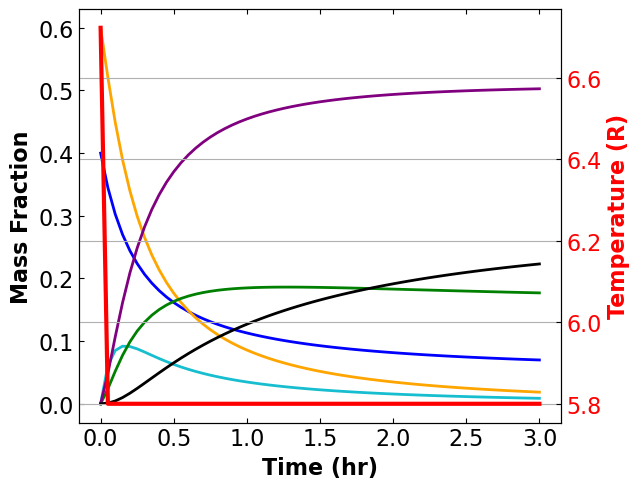

In [27]:
optimal_temp_var = optimize_reactor_var_temp(0.4)

In [28]:
def var_temp_reactor_model(XA0, temp_control_points, meas_sample_time):
    """
    Creates a variable temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp_control_points: dict,
        Piecewise-linear profile of the reaction temperature (in R)
    meas_sample_time: list, 
        Timepoints (in hr) to collect samples for mass fraction measurements

    Returns
    -------
    measured_variables: list containing the mass fraction of all species at the sample timepoints
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == pyo.log(m.a1) - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == pyo.log(m.a2) - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == pyo.log(m.a3) - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - pyo.value(model.XA[t0]))
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # add a piecewise-linear temperature profile
    for t in model.t:
        
        if t < 0.5:
            temp_at_time_t = temp_control_points["0.0"] + 0.2 * t
    
        # elif t < 1.0:
        #     temp_at_time_t = temp_control_points["0.5"] + 0.6 * (t - 0.5)
    
        # else:
        #     temp_at_time_t = 6.2

        elif t < 1.5:
            temp_at_time_t = temp_control_points["0.5"] + 0.4 * (t - 0.5)
    
        else:
            temp_at_time_t = 6.3
    
        model.T_reparam[t].fix(1 / temp_at_time_t)

    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    t_values = [t for t in model.t]
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_values = [1 / pyo.value(model.T_reparam[t]) for t in model.t]

    # plot the temperature and mass fraction profiles
    fig, ax1 = plt.subplots(figsize=(6.5, 5))

    # set the primary axis: mass fraction
    ax1.plot(t_values, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    ax1.plot(t_values, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    ax1.plot(t_values, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    ax1.plot(t_values, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    ax1.plot(t_values, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    ax1.plot(t_values, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    ax1.set_xlabel('Time (hr)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Mass Fraction', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='x', labelsize=16, direction="in", top=True, right=True)
    ax1.tick_params(axis='y', labelsize=16, direction="in", top=True, right=True)

    # set the secondary axis: temperature
    ax2 = ax1.twinx()
    ax2.plot(t_values, temp_values, color='red', linewidth=3)
    ax2.set_ylabel('Temperature (R)', color='red', fontsize=16, fontweight='bold')
    ax2.tick_params(axis='y', labelsize=16, labelcolor='red', direction="in", top=True, right=True)

    # add legend
    plt.grid()
    # ax1.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1.5, 0.5))
    plt.tight_layout()
    plt.savefig("var_temp_mass_profile.png")
    plt.show()

    # store the mass fraction of all species at the sample time
    measured_variables = []
    for sample_time in meas_sample_time:
        measured_variables.append([pyo.value(model.XA[sample_time]), pyo.value(model.XB[sample_time]), 
                                   pyo.value(model.XC[sample_time]), pyo.value(model.XP[sample_time]), 
                                   pyo.value(model.XE[sample_time]), pyo.value(model.XG[sample_time])])

    print("Mass fraction of species at the sample time:",measured_variables)
    return measured_variables

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

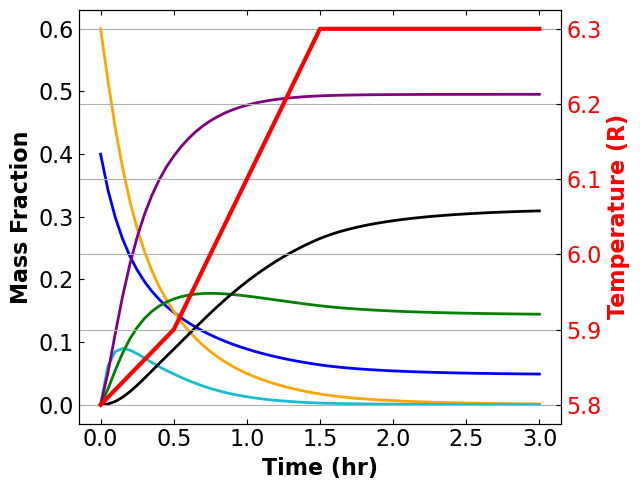

Mass fraction of species at the sample time: [[0.1474655995476528, 0.14906125084355284, 0.049149986364424844, 0.16884929013806885, 0.3968086974081496, 0.08866517569814646], [0.06367227737384547, 0.01718750834425766, 0.002745285670579452, 0.15801445826827, 0.4929695380590068, 0.2654109322840379], [0.04903373205331291, 0.0013149540706428526, 0.00019201219316072378, 0.14456729411517039, 0.49543755596489797, 0.3094544516028133]]

Output variables:
          XA        XB        XC        XP        XE        XG
0  0.147466  0.149061  0.049150  0.168849  0.396809  0.088665
1  0.063672  0.017188  0.002745  0.158014  0.492970  0.265411
2  0.049034  0.001315  0.000192  0.144567  0.495438  0.309454


In [29]:
# define the temperature control points and sample time for mass fraction measurements
temp_control = {"0.0":5.8, "0.5":5.9, "1.0":6.2, "1.5":6.4, "2.0":6.6, "3.0":6.8}

# get the ground-truth simulation of the mass fractions
measured_var = var_temp_reactor_model(0.4, temp_control, sample_time)

# make a dataframe of the measured variables
measured_var_df = ground_truth_data(measured_var)

### Add Gaussian noise to the ground-truth simulations

In [30]:
# generate the noisy mass fraction measurements
noisy_mass_frac_var = generate_noisy_mass_fraction(
    measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
data_var = synthetic_data_compiler(sample_time, noisy_mass_frac_var, 
                                   "batch_reactor_var_temp")

Generated data:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.140538  0.153822  0.051498  0.169287  0.405208  0.079647
1        1.5  0.057087  0.017139  0.003646  0.152238  0.498259  0.271632
2        3.0  0.043095  0.001507  0.000698  0.142639  0.507860  0.304202


### Reformulate the batch reactor model for parameter estimation

In [31]:
def reform_var_temp_reactor_model(XA0, temp_control_points):
    """
    Reformulates the variable temperature batch reactor model for parameter estimation

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp_control_points: dict,
        Piecewise-linear profile of the reaction temperature (in R)

    Returns
    -------
    model: Pyomo model of the variable temperature batch reactor
    
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.alpha_1 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_2 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_3 = pyo.Var(bounds=(0, None), initialize=10)
    model.E1 = pyo.Var(bounds=(0, None), initialize=50)
    model.E2 = pyo.Var(bounds=(0, None), initialize=50)
    model.E3 = pyo.Var(bounds=(0, None), initialize=50)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == model.alpha_1 - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == model.alpha_2 - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == model.alpha_3 - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)
    # model.dXP = dae.DerivativeVar(model.XP, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # @model.Constraint(model.t)
    # def xp_rate_ode(m, t):
    #     if t == m.t.first():
    #         return pyo.Constraint.Skip
    #     return m.dXP[t] == m.k[2, t] * m.XB[t] * m.XC[t] - 0.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA_init = pyo.Constraint(expr=model.XA[t0] == XA0)
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC_init = pyo.Constraint(expr=model.XC[t0] == 0.0)
    model.XE_init = pyo.Constraint(expr=model.XE[t0] == 0.0)
    model.XG_init = pyo.Constraint(expr=model.XG[t0] == 0.0)
    # model.XP_init = pyo.Constraint(expr=model.XP[t0] == 0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # add a piecewise-linear temperature profile
    for t in model.t:
        if t < 0.5:
            temp_at_time_t = temp_control_points["0.0"] + 0.2 * t

        elif t < 1.5:
            temp_at_time_t = temp_control_points["0.5"] + 0.4 * (t - 0.5)
    
        else:
            temp_at_time_t = 6.3
    
        model.T_reparam[t].fix(1 / temp_at_time_t)
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)
    
    return model

### Estimate the unknown model parameters

In [32]:
objective_val, estimated_params, cov_matrix_est = parameter_covariance_est(data_var, XA0=0.4, 
                                                                           temp_control=temp_control, 
                                                                           const_temp=False)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [33]:
print("Estimates of the original parameters:\n",estimated_params)
print("\nCovariance matrix of the original parameters:\n",cov_matrix_est)
print(np.linalg.cond(cov_matrix_est))

Estimates of the original parameters:
 {'a1': np.float64(21770306000.572758), 'a2': np.float64(42120652683.63305), 'a3': np.float64(2927736006245835.5), 'E1': 127.80409915259929, 'E2': 125.981327539574, 'E3': 193.64320457292905}

Covariance matrix of the original parameters:
               a1            a2            a3            E1            E2  \
a1  5.795473e+20 -1.732197e+21  1.053078e+26  1.567300e+11 -2.434581e+11   
a2 -1.732197e+21  4.466536e+22  5.579594e+26 -4.721125e+11  6.251028e+12   
a3  1.053078e+26  5.579594e+26  1.820621e+32  2.884243e+16  7.720948e+16   
E1  1.567300e+11 -4.721125e+11  2.884243e+16  4.238969e+01 -6.635496e+01   
E2 -2.434581e+11  6.251028e+12  7.720948e+16 -6.635496e+01  8.748621e+02   
E3  2.174836e+11  1.043397e+12  3.697888e+17  5.956960e+01  1.442387e+02   

              E3  
a1  2.174836e+11  
a2  1.043397e+12  
a3  3.697888e+17  
E1  5.956960e+01  
E2  1.442387e+02  
E3  7.513315e+02  
8.834289828127066e+34


## Implement the temperature profile obtained from experimental design

### A-optimal design

In [34]:
# load the design conditions from optimal experimental design
trc_optimal_design = pd.read_csv("trace_optimal_design_cond.csv")
time_vals = trc_optimal_design["Time (hr)"]
trc_optimal_temp = trc_optimal_design["Temperature (1/R)"]
trc_optimal_XA0 = trc_optimal_design["XA"][0]

In [35]:
def optimal_exp_design_model(XA0, meas_sample_time, temp_profile, expert_profile=False):
    """
    Creates a variable temperature Pyomo model for the batch reactor

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    meas_sample_time: list, 
        Timepoints (in hr) to collect samples for mass fraction measurements
    temp_profile: Pandas series or list,
        Temperature profile from optimal experimental design
    expert_profile: Boolean,
        Specifies if we are using an expert intuition for the temperature profile

    Returns
    -------
    measured_variables: list containing the mass fraction of all species at the sample timepoints
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.a1 = pyo.Param(within=pyo.PositiveReals, initialize=5.9755 * 10**9)
    model.a2 = pyo.Param(within=pyo.PositiveReals, initialize=2.5962 * 10**12)
    model.a3 = pyo.Param(within=pyo.PositiveReals, initialize=9.6283 * 10**15)
    model.E1 = pyo.Param(within=pyo.PositiveReals, initialize=120)
    model.E2 = pyo.Param(within=pyo.PositiveReals, initialize=150)
    model.E3 = pyo.Param(within=pyo.PositiveReals, initialize=200)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == pyo.log(m.a1) - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == pyo.log(m.a2) - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == pyo.log(m.a3) - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA[t0].fix(XA0)
    model.XB[t0].fix(1 - XA0)
    model.XC[t0].fix(0.0)
    model.XE[t0].fix(0.0)
    model.XG[t0].fix(0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # add the optimal temperature profile
    for indx, t in enumerate(time_vals):
        if not expert_profile:
            model.T_reparam[t].fix(temp_profile[indx])
        else:
            model.T_reparam[t].fix(1/temp_profile[0])

    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)

    # get the mass fraction of all species
    t_values = [t for t in model.t]
    XA_values = [pyo.value(model.XA[t]) for t in model.t]
    XB_values = [pyo.value(model.XB[t]) for t in model.t] 
    XC_values = [pyo.value(model.XC[t]) for t in model.t] 
    XP_values = [pyo.value(model.XP[t]) for t in model.t] 
    XE_values = [pyo.value(model.XE[t]) for t in model.t] 
    XG_values = [pyo.value(model.XG[t]) for t in model.t]

    # get the temperature
    temp_values = [1 / pyo.value(model.T_reparam[t]) for t in model.t]

    # plot the temperature and mass fraction profiles
    fig, ax1 = plt.subplots(figsize=(6.5, 5))

    # set the primary axis: mass fraction
    ax1.plot(t_values, XA_values, label='X$_\mathbf{A}$', color='blue', linewidth=2)
    ax1.plot(t_values, XB_values, label='X$_\mathbf{B}$', color='orange', linewidth=2)
    ax1.plot(t_values, XC_values, label='X$_\mathbf{C}$', color='tab:cyan', linewidth=2)
    ax1.plot(t_values, XP_values, label='X$_\mathbf{P}$', color='green', linewidth=2)
    ax1.plot(t_values, XE_values, label='X$_\mathbf{E}$', color='purple', linewidth=2)
    ax1.plot(t_values, XG_values, label='X$_\mathbf{G}$', color='black', linewidth=2)

    ax1.set_xlabel('Time (hr)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Mass Fraction', fontsize=16, fontweight='bold')
    ax1.tick_params(axis='x', labelsize=16, direction="in", top=True, right=True)
    ax1.tick_params(axis='y', labelsize=16, direction="in", top=True, right=True)

    # set the secondary axis: temperature
    ax2 = ax1.twinx()
    ax2.plot(t_values, temp_values, color='red', linewidth=3)
    ax2.set_ylabel('Temperature (R)', color='red', fontsize=16, fontweight='bold')
    ax2.tick_params(axis='y', labelsize=16, labelcolor='red', direction="in", top=True, right=True)

    # add legend
    plt.grid()
    ax1.legend(prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1.5, 0.5))
    plt.tight_layout()
    plt.show()

    # store the mass fraction of all species at the sample time
    measured_variables = []
    for sample_time in meas_sample_time:
        measured_variables.append([pyo.value(model.XA[sample_time]), pyo.value(model.XB[sample_time]), 
                                   pyo.value(model.XC[sample_time]), pyo.value(model.XP[sample_time]), 
                                   pyo.value(model.XE[sample_time]), pyo.value(model.XG[sample_time])])

    print("Mass fraction of species at the sample time:",measured_variables)
    return measured_variables

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

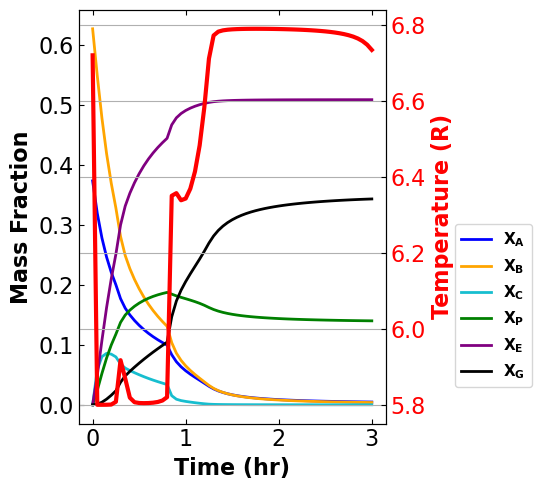

Mass fraction of species at the sample time: [[0.13246784500865608, 0.1933438117341127, 0.050066044016553325, 0.1694844275737784, 0.38523646175529386, 0.06940140991160554], [0.016649065590627687, 0.01649931080138046, 0.0002764655212055656, 0.15082230193748386, 0.5072879047847015, 0.308464951364601], [0.004578723380652605, 0.0037775622317053705, 2.1703644349121594e-05, 0.13992739150848038, 0.5085907175041017, 0.3431039017307109]]

Output variables:
          XA        XB        XC        XP        XE        XG
0  0.132468  0.193344  0.050066  0.169484  0.385236  0.069401
1  0.016649  0.016499  0.000276  0.150822  0.507288  0.308465
2  0.004579  0.003778  0.000022  0.139927  0.508591  0.343104
Generated data:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.125089  0.199437  0.052441  0.169941  0.393288  0.059804
1        1.5  0.009510  0.016442  0.001148  0.144961  0.512746  0.315193
2        3.0  0.000000  0.004068  0.000518  0.137322  0.519852 

In [36]:
# get the ground-truth simulation of the mass fractions
trc_measured_var = optimal_exp_design_model(trc_optimal_XA0, sample_time, 
                                            temp_profile=trc_optimal_temp)

# make a dataframe of the measured variables
trc_measured_var_df = ground_truth_data(trc_measured_var)

# generate the noisy mass fraction measurements
trc_noisy_mass_frac_var = generate_noisy_mass_fraction(
    trc_measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
trc_data_var = synthetic_data_compiler(sample_time, trc_noisy_mass_frac_var, 
                                       "batch_reactor_trc_var_temp")

### Reformulate the batch reactor model for parameter estimation

In [37]:
def reform_optimal_exp_design_model(XA0, temp_profile, expert_profile=False):
    """
    Reformulates the variable temperature batch reactor model for parameter estimation

    Parameters
    ----------
    XA0: float,
        Initial mass fraction of species A
    temp_profile: Pandas series or list,
        Temperature profile from optimal experimental design
    expert_profile: Boolean,
        Specifies if we are using an expert intuition for the temperature profile

    Returns
    -------
    model: Pyomo model of the variable temperature batch reactor
    
    """
    model = pyo.ConcreteModel()

    # define sets
    reaction_number = [1, 2, 3]
    model.t = dae.ContinuousSet(bounds=[0, 3]) # hour

    # define the model parameters
    model.alpha_1 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_2 = pyo.Var(bounds=(0, None), initialize=10)
    model.alpha_3 = pyo.Var(bounds=(0, None), initialize=10)
    model.E1 = pyo.Var(bounds=(0, None), initialize=50)
    model.E2 = pyo.Var(bounds=(0, None), initialize=50)
    model.E3 = pyo.Var(bounds=(0, None), initialize=50)
    
    # add the mass fraction variables
    model.XA = pyo.Var(model.t, bounds=(0, 1), initialize=XA0)
    model.XB = pyo.Var(model.t, bounds=(0, 1), initialize=1-XA0)
    model.XC = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XE = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XP = pyo.Var(model.t, bounds=(0, 1), initialize=0)
    model.XG = pyo.Var(model.t, bounds=(0, 1), initialize=0)

    # add the temperature variables
    model.T_reparam = pyo.Var(model.t, bounds=(0, 1))

    # add the rate constants
    model.k_reparam = pyo.Var(reaction_number, model.t, bounds=(0, None))
    model.k = pyo.Var(reaction_number, model.t, bounds=(0, None))
    
    # calculate the reparameterized rate constants
    def k_reparam_rule(m, i, t):
        if i == 1:
            return m.k_reparam[i, t] == model.alpha_1 - m.E1 * m.T_reparam[t]
        elif i == 2:
            return m.k_reparam[i, t] == model.alpha_2 - m.E2 * m.T_reparam[t]
        else:
            return m.k_reparam[i, t] == model.alpha_3 - m.E3 * m.T_reparam[t]
            
    model.k_reparam_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_reparam_rule
    )
    
    # calculate the original rate constants
    def k_rule(m, i, t):
        return m.k[i, t] == pyo.exp(m.k_reparam[i, t])
    
    model.k_eq = pyo.Constraint(
        reaction_number, model.t, rule=k_rule
    )

    # add the differential equations for XA, XB, XC, XE, XP, and XG
    model.dXA = dae.DerivativeVar(model.XA, wrt=model.t)
    model.dXB = dae.DerivativeVar(model.XB, wrt=model.t)
    model.dXC = dae.DerivativeVar(model.XC, wrt=model.t)
    model.dXE = dae.DerivativeVar(model.XE, wrt=model.t)
    model.dXG = dae.DerivativeVar(model.XG, wrt=model.t)
    # model.dXP = dae.DerivativeVar(model.XP, wrt=model.t)

    @model.Constraint(model.t)
    def xa_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXA[t] == - m.k[1, t] * m.XA[t] * m.XB[t]
    
    @model.Constraint(model.t)
    def xb_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXB[t] == - (m.k[1, t] * m.XA[t] * m.XB[t] + m.k[2, t] * m.XB[t] * m.XC[t])
    
    @model.Constraint(model.t)
    def xc_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXC[t] == 2 * m.k[1, t] * m.XA[t] * m.XB[t] - 2 * m.k[2, t] * m.XB[t] * m.XC[t] - m.k[3, t] * m.XC[t] * m.XP[t]
    
    @model.Constraint(model.t)
    def xe_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXE[t] == 2 * m.k[2, t] * m.XB[t] * m.XC[t]
    
    @model.Constraint(model.t)
    def xg_rate_ode(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dXG[t] == 1.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # @model.Constraint(model.t)
    # def xp_rate_ode(m, t):
    #     if t == m.t.first():
    #         return pyo.Constraint.Skip
    #     return m.dXP[t] == m.k[2, t] * m.XB[t] * m.XC[t] - 0.5 * m.k[3, t] * m.XC[t] * m.XP[t]

    # add the mass fraction constraint
    @model.Constraint(model.t)
    def sum_mass_fraction(m, t):
        return m.XA[t] + m.XB[t] + m.XC[t] + m.XE[t] + m.XG[t] + m.XP[t] == 1

    # fix the initial conditions
    t0 = model.t.first()
    model.XA_init = pyo.Constraint(expr=model.XA[t0] == XA0)
    model.XB_init = pyo.Constraint(expr=model.XB[t0] == 1 - model.XA[t0])
    model.XC_init = pyo.Constraint(expr=model.XC[t0] == 0.0)
    model.XE_init = pyo.Constraint(expr=model.XE[t0] == 0.0)
    model.XG_init = pyo.Constraint(expr=model.XG[t0] == 0.0)
    # model.XP_init = pyo.Constraint(expr=model.XP[t0] == 0.0)

    # discretize the model
    disc = pyo.TransformationFactory("dae.finite_difference")
    disc.apply_to(model, nfe=60, scheme="BACKWARD")

    # add the optimal temperature profile
    for indx, t in enumerate(time_vals):
        if not expert_profile:
            model.T_reparam[t].fix(temp_profile[indx])
        else:
            model.T_reparam[t].fix(1/temp_profile[0])
    
    # define the solver
    solver = pyo.SolverFactory('ipopt')
    
    # solve the model
    results = solver.solve(model, tee=True)
    
    return model

### Estimate the unknown model parameters

In [38]:
theta_ref = {'alpha_1': 23.803812768160174, 'alpha_2': 24.463804019909027, 'alpha_3': 35.61300582514381, 
               'E1': 127.80409915259551, 'E2': 125.98132753959848, 'E3': 193.6432045729297}

prior_FIM = np.array([
        [1.642115e+04, 1.318845e+03, -1.527089e+03, -2.798949e+03, -2.228744e+02, 2.595965e+02],
        [1.318845e+03, 3.470710e+03, -2.317680e+02, -2.266803e+02, -5.883556e+02, 3.791954e+01],
        [-1.527089e+03, -2.317680e+02, 7.473955e+02, 2.597131e+02, 3.765902e+01, -1.255188e+02],
        [-2.798949e+03, -2.266803e+02, 2.597131e+02, 4.771091e+02, 3.831287e+01, -4.415367e+01],
        [-2.228744e+02, -5.883556e+02, 3.765902e+01, 3.831287e+01, 9.974374e+01, -6.155345e+00],
        [2.595965e+02, 3.791954e+01, -1.255188e+02, -4.415367e+01, -6.155345e+00, 2.108267e+01]
    ])

prior_FIM_df = pd.DataFrame(
                            prior_FIM,
                            index=["alpha_1", "alpha_2", "alpha_3", "E1", "E2", "E3"],
                            columns=["alpha_1", "alpha_2", "alpha_3", "E1", "E2", "E3"],)
print(prior_FIM_df)

            alpha_1     alpha_2     alpha_3          E1          E2  \
alpha_1  16421.1500  1318.84500 -1527.08900 -2798.94900 -222.874400   
alpha_2   1318.8450  3470.71000  -231.76800  -226.68030 -588.355600   
alpha_3  -1527.0890  -231.76800   747.39550   259.71310   37.659020   
E1       -2798.9490  -226.68030   259.71310   477.10910   38.312870   
E2        -222.8744  -588.35560    37.65902    38.31287   99.743740   
E3         259.5965    37.91954  -125.51880   -44.15367   -6.155345   

                 E3  
alpha_1  259.596500  
alpha_2   37.919540  
alpha_3 -125.518800  
E1       -44.153670  
E2        -6.155345  
E3        21.082670  


In [39]:
obj_trc, est_params_trc, cov_matrix_trc = parameter_covariance_est(trc_data_var, XA0=trc_optimal_XA0, 
                                                                       temp_control=trc_optimal_temp, 
                                                                       const_temp=False, prior_est=True,
                                                                       prior_FIM=prior_FIM_df, theta_ref=theta_ref)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [40]:
print("Estimates of the original parameters:\n",est_params_trc)
print("\nCovariance matrix of the original parameters:\n",cov_matrix_trc)

Estimates of the original parameters:
 {'a1': np.float64(12794173336.176844), 'a2': np.float64(1152660604252.464), 'a3': np.float64(1.1573968973082768e+16), 'E1': 124.69229508205004, 'E2': 145.51202446717167, 'E3': 201.6395868471167}

Covariance matrix of the original parameters:
               a1            a2            a3            E1            E2  \
a1  4.625048e+19 -7.212131e+20  4.571645e+25  2.119502e+10 -3.798374e+09   
a2 -7.212131e+20  6.101935e+24  5.186168e+28 -3.402726e+11  3.102566e+13   
a3  4.571645e+25  5.186168e+28  8.215507e+32  2.132367e+16  2.627461e+17   
E1  2.119502e+10 -3.402726e+11  2.132367e+16  9.714870e+00 -1.791789e+00   
E2 -3.798374e+09  3.102566e+13  2.627461e+17 -1.791789e+00  1.577593e+02   
E3  2.364934e+10  2.607480e+13  4.200242e+17  1.103670e+01  1.320865e+02   

              E3  
a1  2.364934e+10  
a2  2.607480e+13  
a3  4.200242e+17  
E1  1.103670e+01  
E2  1.320865e+02  
E3  2.148399e+02  


### D-optimal design

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

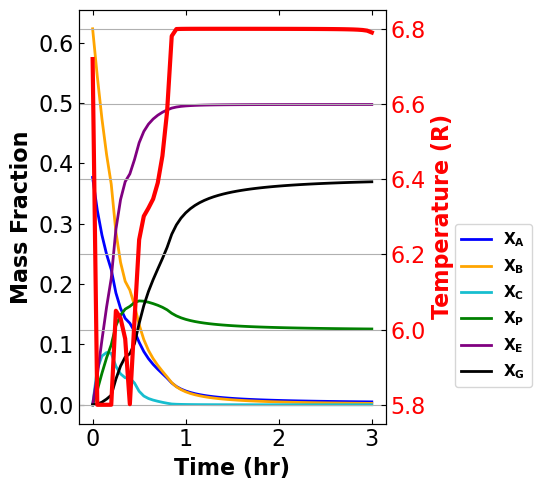

Mass fraction of species at the sample time: [[0.10355756200796601, 0.1326946729040828, 0.022357838941575683, 0.17220877824057262, 0.43432299305100824, 0.1348581548547946], [0.010604787139749805, 0.008251347697363689, 0.00010239563442721165, 0.13110938239578787, 0.4973040937280141, 0.3526279934046574], [0.00480271743435805, 0.0022609419339834325, 1.3886340243468078e-05, 0.12563973015928118, 0.4976807658439908, 0.369601958288143]]

Output variables:
          XA        XB        XC        XP        XE        XG
0  0.103558  0.132695  0.022358  0.172209  0.434323  0.134858
1  0.010605  0.008251  0.000102  0.131109  0.497304  0.352628
2  0.004803  0.002261  0.000014  0.125640  0.497681  0.369602
Generated data:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.095309  0.136963  0.023899  0.172748  0.443851  0.127230
1        1.5  0.003394  0.008097  0.000972  0.125016  0.502645  0.359877
2        3.0  0.000000  0.002488  0.000510  0.122462  0.508602

In [41]:
# load the design conditions from optimal experimental design
det_optimal_design = pd.read_csv("determinant_optimal_design_cond.csv")
det_optimal_temp = det_optimal_design["Temperature (1/R)"]
det_optimal_XA0 = det_optimal_design["XA"][0]

# get the ground-truth simulation of the mass fractions
det_measured_var = optimal_exp_design_model(det_optimal_XA0, sample_time, 
                                            temp_profile=det_optimal_temp)

# make a dataframe of the measured variables
det_measured_var_df = ground_truth_data(det_measured_var)

# generate the noisy mass fraction measurements
det_noisy_mass_frac_var = generate_noisy_mass_fraction(
    det_measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
det_data_var = synthetic_data_compiler(sample_time, det_noisy_mass_frac_var, 
                                       "batch_reactor_det_var_temp")

In [42]:
obj_det, est_params_det, cov_matrix_det = parameter_covariance_est(det_data_var, XA0=det_optimal_XA0, 
                                                                   temp_control=det_optimal_temp, 
                                                                   const_temp=False, prior_est=True,
                                                                   prior_FIM=prior_FIM_df, theta_ref=theta_ref)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [43]:
print("Estimates of the original parameters:\n",est_params_det)
print("\nCovariance matrix of the original parameters:\n",cov_matrix_det)

Estimates of the original parameters:
 {'a1': np.float64(7652600236.781511), 'a2': np.float64(1681294189676.7263), 'a3': np.float64(9995362443626950.0), 'E1': 121.68408423704976, 'E2': 147.71127354295834, 'E3': 200.68328813495384}

Covariance matrix of the original parameters:
               a1            a2            a3            E1            E2  \
a1  1.385764e+19  8.438201e+19  1.629738e+25  1.071833e+10  2.196265e+08   
a2  8.438201e+19  2.547271e+24  1.035655e+28  6.697677e+10  8.988769e+12   
a3  1.629738e+25  1.035655e+28  1.873110e+32  1.282972e+16  3.614356e+16   
E1  1.071833e+10  6.697677e+10  1.282972e+16  8.292221e+00  1.749343e-01   
E2  2.196265e+08  8.988769e+12  3.614356e+16  1.749343e-01  3.172861e+01   
E3  9.747107e+09  6.068506e+12  1.130819e+17  7.678616e+00  2.117395e+01   

              E3  
a1  9.747107e+09  
a2  6.068506e+12  
a3  1.130819e+17  
E1  7.678616e+00  
E2  2.117395e+01  
E3  6.831739e+01  


### E-optimal design

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

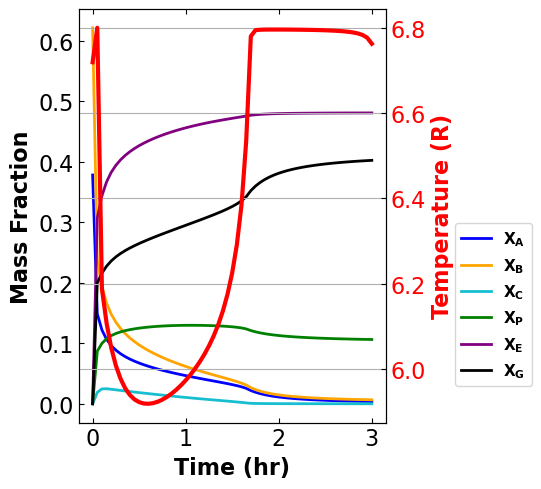

Mass fraction of species at the sample time: [[0.06731976914227182, 0.09729762160287228, 0.018491044007181556, 0.12506847592615888, 0.4268114068399968, 0.2650116824815187], [0.031706592372398854, 0.03907654783133083, 0.0037043229556992614, 0.12727773263388165, 0.4720272008433335, 0.32620760336335586], [0.0036483441338490937, 0.0065553033265096546, 3.654943127614195e-05, 0.10631159016566286, 0.4809531933758768, 0.4024950195668255]]

Output variables:
          XA        XB        XC        XP        XE        XG
0  0.067320  0.097298  0.018491  0.125068  0.426811  0.265012
1  0.031707  0.039077  0.003704  0.127278  0.472027  0.326208
2  0.003648  0.006555  0.000037  0.106312  0.480953  0.402495
Generated data:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.057980  0.100501  0.019916  0.124189  0.436114  0.261301
1        1.5  0.024745  0.039286  0.004616  0.121139  0.477070  0.333145
2        3.0  0.000000  0.006956  0.000533  0.102193  0.49057

In [44]:
# load the design conditions from optimal experimental design
eig_optimal_design = pd.read_csv("minimum_eigenvalue_optimal_design_cond.csv")
eig_optimal_temp = eig_optimal_design["Temperature (1/R)"]
eig_optimal_XA0 = eig_optimal_design["XA"][0]

# get the ground-truth simulation of the mass fractions
eig_measured_var = optimal_exp_design_model(eig_optimal_XA0, sample_time, 
                                            temp_profile=eig_optimal_temp)

# make a dataframe of the measured variables
eig_measured_var_df = ground_truth_data(eig_measured_var)

# generate the noisy mass fraction measurements
eig_noisy_mass_frac_var = generate_noisy_mass_fraction(
    eig_measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
eig_data_var = synthetic_data_compiler(sample_time, eig_noisy_mass_frac_var, 
                                       "batch_reactor_eig_var_temp")

In [45]:
obj_eig, est_params_eig, cov_matrix_eig = parameter_covariance_est(eig_data_var, XA0=eig_optimal_XA0, 
                                                                   temp_control=eig_optimal_temp, 
                                                                   const_temp=False, prior_est=True,
                                                                   prior_FIM=prior_FIM_df, theta_ref=theta_ref)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [46]:
print("Estimates of the original parameters:\n",est_params_eig)
print("\nCovariance matrix of the original parameters:\n",cov_matrix_eig)

Estimates of the original parameters:
 {'a1': np.float64(6012698952.697246), 'a2': np.float64(393075652917.17914), 'a3': np.float64(3374374874159171.5), 'E1': 120.24890533168048, 'E2': 139.17357501181598, 'E3': 194.3504164421726}

Covariance matrix of the original parameters:
               a1            a2            a3            E1            E2  \
a1  3.351548e+18  1.651401e+20  2.742187e+24  3.314170e+09  2.460573e+09   
a2  1.651401e+20  8.009983e+23  5.867665e+27  1.597377e+11  1.201260e+13   
a3  2.742187e+24  5.867665e+27  5.062965e+31  2.722329e+15  8.788864e+16   
E1  3.314170e+09  1.597377e+11  2.722329e+15  3.279409e+00  2.378816e+00   
E2  2.460573e+09  1.201260e+13  8.788864e+16  2.378816e+00  1.801636e+02   
E3  4.915789e+09  1.020798e+13  8.874965e+16  4.885578e+00  1.528955e+02   

              E3  
a1  4.915789e+09  
a2  1.020798e+13  
a3  8.874965e+16  
E1  4.885578e+00  
E2  1.528955e+02  
E3  1.556479e+02  


### Model-free expert intuition

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

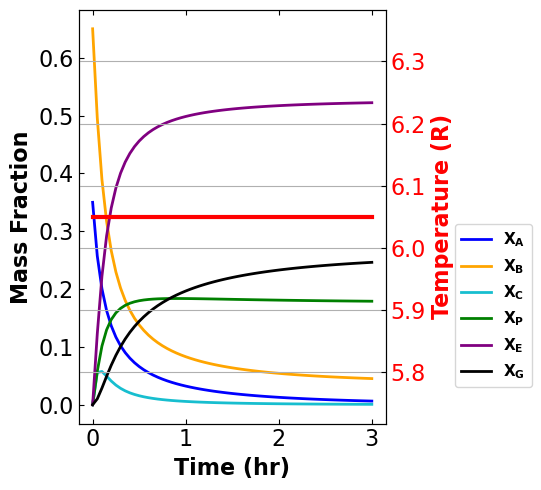

Mass fraction of species at the sample time: [[0.06612104691563017, 0.13814261802000896, 0.015620878272021984, 0.17988835512072984, 0.4559568647919694, 0.14427023680900686], [0.019521816910189508, 0.06387493935625073, 0.0029753441123781237, 0.1823032882249315, 0.5112937784323324, 0.22003083291759537], [0.0064181203991410096, 0.04530818046108715, 0.00077906394006116, 0.17902762881241316, 0.5222199232762178, 0.24624708300691853]]

Output variables:
          XA        XB        XC        XP        XE        XG
0  0.066121  0.138143  0.015621  0.179888  0.455957  0.144270
1  0.019522  0.063875  0.002975  0.182303  0.511294  0.220031
2  0.006418  0.045308  0.000779  0.179028  0.522220  0.246247
Generated data:
    Time (hr)        XA        XB        XC        XP        XE        XG
0        0.5  0.056745  0.142575  0.016959  0.180659  0.466136  0.136926
1        1.5  0.012416  0.064376  0.003878  0.176813  0.516799  0.225717
2        3.0  0.000000  0.047437  0.001310  0.178409  0.535080  

In [47]:
# load the design conditions from the model-free expert intuition
expt_temp = [6.05]
expt_optimal_XA0 = 0.35

# get the ground-truth simulation of the mass fractions
expt_measured_var = optimal_exp_design_model(expt_optimal_XA0, sample_time, 
                                             temp_profile=expt_temp, expert_profile=True)

# make a dataframe of the measured variables
expt_measured_var_df = ground_truth_data(expt_measured_var)

# generate the noisy mass fraction measurements
expt_noisy_mass_frac_var = generate_noisy_mass_fraction(
    expt_measured_var_df,
    species_cols=species,
    standard_dev=std_dict,
)

# compile the generated data into a csv file
expt_data_var = synthetic_data_compiler(sample_time, expt_noisy_mass_frac_var, 
                                        "batch_reactor_expert_var_temp")

In [48]:
obj_expt, est_params_expt, cov_matrix_expt = parameter_covariance_est(expt_data_var, XA0=expt_optimal_XA0, 
                                                                     temp_control=expt_temp, 
                                                                     const_temp=False, prior_est=True, 
                                                                     prior_FIM=prior_FIM_df, 
                                                                     theta_ref=theta_ref,
                                                                     expert_profile=True,)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [49]:
print("Estimates of the original parameters:\n",est_params_expt)
print("\nCovariance matrix of the original parameters:\n",cov_matrix_expt)

Estimates of the original parameters:
 {'a1': np.float64(5999850416.123657), 'a2': np.float64(432041182658.7677), 'a3': np.float64(1.1303416590671184e+16), 'E1': 120.25343610736297, 'E2': 139.71653542616625, 'E3': 201.49505457914037}

Covariance matrix of the original parameters:
               a1            a2            a3            E1            E2  \
a1  1.000253e+19 -7.983542e+20  5.879902e+25  9.914474e+09 -1.102908e+10   
a2 -7.983542e+20  6.463373e+23  2.838785e+27 -7.927379e+11  8.846821e+12   
a3  5.879902e+25  2.838785e+27  1.219521e+33  5.884198e+16  3.685698e+16   
E1  9.914474e+09 -7.927379e+11  5.884198e+16  9.829421e+00 -1.095263e+01   
E2 -1.102908e+10  8.846821e+12  3.685698e+16 -1.095263e+01  1.211039e+02   
E3  3.136884e+10  1.344501e+12  6.476843e+17  3.139411e+01  1.734616e+01   

              E3  
a1  3.136884e+10  
a2  1.344501e+12  
a3  6.476843e+17  
E1  3.139411e+01  
E2  1.734616e+01  
E3  3.440494e+02  


## Confidence regions

In [50]:
def likelihood_confidence_ellipse(opt_design_params, opt_design_cov, 
                                  param_index, confidence_level=0.80, 
                                  grid_points=300,):
    # define the parameters and covariance from optimal design using numpy
    theta_hat = np.array([
        opt_design_params["a1"],
        opt_design_params["a2"],
        opt_design_params["a3"],
        opt_design_params["E1"],
        opt_design_params["E2"],
        opt_design_params["E3"]
    ])
    cov = opt_design_cov.to_numpy()

    # define the parameters and covariance from expert intuition using numpy
    theta_hat_expt = np.array([
        est_params_expt["a1"], 
        est_params_expt["a2"], 
        est_params_expt["a3"],
        est_params_expt["E1"], 
        est_params_expt["E2"], 
        est_params_expt["E3"]])
    cov_expt = cov_matrix_expt.to_numpy()

    # define the parameters and covariance from the prevoius experiment using numpy
    theta_hat_prev = np.array([
        estimated_params["a1"], 
        estimated_params["a2"], 
        estimated_params["a3"],
        estimated_params["E1"], 
        estimated_params["E2"], 
        estimated_params["E3"]])
    cov_prev = cov_matrix_est.to_numpy()
    
    # get the parameters of interest
    theta_sub = theta_hat[param_index]
    theta_sub_expt = theta_hat_expt[param_index]
    theta_sub_prev = theta_hat_prev[param_index]
    
    # get the covariance matrix of interest
    cov_sub = cov[np.ix_(param_index, param_index)]
    cov_sub_inv = np.linalg.inv(cov_sub)
    
    cov_sub_expt = cov_expt[np.ix_(param_index, param_index)]
    cov_sub_inv_expt = np.linalg.inv(cov_sub_expt)
    
    cov_sub_prev = cov_prev[np.ix_(param_index, param_index)]
    cov_sub_inv_prev = np.linalg.inv(cov_sub_prev)
    
    # define the chi-squared threshold
    cutoff = chi2.ppf(confidence_level, df=2)
    
    # define the grid of the parameters from the optimal design
    param_1_grid = np.linspace(
        theta_sub[0] - 4 * np.sqrt(cov_sub[0,0]),
        theta_sub[0] + 4 * np.sqrt(cov_sub[0,0]),
        grid_points
    )
    
    param_2_grid = np.linspace(
        theta_sub[1] - 4 * np.sqrt(cov_sub[1,1]),
        theta_sub[1] + 4 * np.sqrt(cov_sub[1,1]),
        grid_points
    )
    
    A, B = np.meshgrid(param_1_grid, param_2_grid)
    
    # define the grid of the parameters from the expert intuition
    param_1_grid_expt = np.linspace(
        theta_sub_expt[0] - 4 * np.sqrt(cov_sub_expt[0,0]),
        theta_sub_expt[0] + 4 * np.sqrt(cov_sub_expt[0,0]),
        grid_points
    )
    
    param_2_grid_expt = np.linspace(
        theta_sub_expt[1] - 4 * np.sqrt(cov_sub_expt[1,1]),
        theta_sub_expt[1] + 4 * np.sqrt(cov_sub_expt[1,1]),
        grid_points
    )
    
    A_expt, B_expt = np.meshgrid(param_1_grid_expt, param_2_grid_expt)
    
    # define the grid of the parameters from the prior experiment
    param_1_grid_prev = np.linspace(
        theta_sub_prev[0] - 4 * np.sqrt(cov_sub_prev[0,0]),
        theta_sub_prev[0] + 4 * np.sqrt(cov_sub_prev[0,0]),
        grid_points
    )
    
    param_2_grid_prev = np.linspace(
        theta_sub_prev[1] - 4 * np.sqrt(cov_sub_prev[1,1]),
        theta_sub_prev[1] + 4 * np.sqrt(cov_sub_prev[1,1]),
        grid_points
    )
    
    A_prev, B_prev = np.meshgrid(param_1_grid_prev, param_2_grid_prev)
    
    # compute the likelihood ratio statistics
    LR_stats = np.zeros_like(A)
    LR_stats_expt = np.zeros_like(A)
    LR_stats_prev = np.zeros_like(A)

    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            # compute the difference between the current parameters 
            # and the estimated parameters
            d = np.array([
                A[i,j] - theta_sub[0],
                B[i,j] - theta_sub[1]
            ])
            d_expt = np.array([
                A_expt[i,j] - theta_sub_expt[0],
                B_expt[i,j] - theta_sub_expt[1]
            ])
    
            d_prev = np.array([
                A_prev[i,j] - theta_sub_prev[0],
                B_prev[i,j] - theta_sub_prev[1]
            ])

            # update the likelihood ratio statistics
            LR_stats[i,j] = d @ cov_sub_inv @ d
            LR_stats_expt[i,j] = d_expt @ cov_sub_inv_expt @ d_expt
            LR_stats_prev[i,j] = d_prev @ cov_sub_inv_prev @ d_prev

    return cutoff, np.array([[A_prev, B_prev, LR_stats_prev], [A_expt, B_expt, LR_stats_expt], [A, B, LR_stats]])
    
    

In [51]:
def plot_confidence_region(cutoff, LR_mat, labels, fig_name):
    fig = plt.subplots(figsize=(7, 7))

    # original experiment color
    prev_fill = "#F4A582"
    prev_edge = "#D6604D"
    
    # model-free color
    expert_fill = "#92C5DE"
    expert_edge = "#0571B0"
    
    # Optimal design color
    current_fill = "#B8E186"
    current_edge = "#4D9221"
    
    alpha_fill = 0.25
    lw = 2.5

    # define the parameters that need to be scaled for the plots
    scaled_params = ["a1", "a2", "a3"]

    # define a container for all the activation energy
    E_params = ["E1", "E2", "E3"]

    if all(item not in fig_name for item in scaled_params):
        # plot the confidence regions
        plt.contourf(LR_mat[0,0], LR_mat[0,1], np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                     levels=[0.5, 1.5], colors=[prev_fill], alpha=alpha_fill)
        
        plt.contourf(LR_mat[1,0], LR_mat[1,1], np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                     levels=[0.5, 1.5], colors=[expert_fill], alpha=alpha_fill)
        
        plt.contourf(LR_mat[2,0], LR_mat[2,1], np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                     levels=[0.5, 1.5], colors=[current_fill], alpha=alpha_fill)
        
        # plot the boundaries of the confidence regions
        plt.contour(LR_mat[0,0], LR_mat[0,1], LR_mat[0,2], 
                    levels=[cutoff], colors=[prev_edge], linewidths=lw,)
    
        plt.contour(LR_mat[1,0], LR_mat[1,1], LR_mat[1,2], 
                    levels=[cutoff], colors=[expert_edge], linewidths=lw,)
        
        plt.contour(LR_mat[2,0], LR_mat[2,1], LR_mat[2,2], 
                    levels=[cutoff], colors=[current_edge], linewidths=lw,)

        if fig_name == ["E1", "E3"]:
            # plot the true value of the parameters
            plt.scatter(true_params["E1"], true_params["E3"], marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((112, 142))
            plt.ylim((135, 250))
            
        elif fig_name == ["E1", "E2"]:
            plt.scatter(true_params["E1"], true_params["E2"], marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((112, 142))
            plt.ylim((60, 190))
            
        elif fig_name == ["E2", "E3"]:
            plt.scatter(true_params["E2"], true_params["E3"], marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((60, 190))
            plt.ylim((135, 250))
            
    elif all(item not in fig_name for item in E_params):
        if fig_name == ["a1", "a2"]:
            # plot the confidence regions
            plt.contourf(LR_mat[0,0]/1e9, LR_mat[0,1]/1e11, np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[prev_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[1,0]/1e9, LR_mat[1,1]/1e11, np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[expert_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[2,0]/1e9, LR_mat[2,1]/1e11, np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[current_fill], alpha=alpha_fill)
            
            # plot the boundaries of the confidence regions
            plt.contour(LR_mat[0,0]/1e9, LR_mat[0,1]/1e11, LR_mat[0,2], 
                        levels=[cutoff], colors=[prev_edge], linewidths=lw,)
        
            plt.contour(LR_mat[1,0]/1e9, LR_mat[1,1]/1e11, LR_mat[1,2], 
                        levels=[cutoff], colors=[expert_edge], linewidths=lw,)
            
            plt.contour(LR_mat[2,0]/1e9, LR_mat[2,1]/1e11, LR_mat[2,2], 
                        levels=[cutoff], colors=[current_edge], linewidths=lw,)
            
            plt.scatter(true_params["a1"]/1e9, true_params["a2"]/1e11, marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((-30, 70))
            plt.ylim((-20, 50))
            
        elif fig_name == ["a1", "a3"]:
            # plot the confidence regions
            plt.contourf(LR_mat[0,0]/1e9, LR_mat[0,1]/1e15, np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[prev_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[1,0]/1e9, LR_mat[1,1]/1e15, np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[expert_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[2,0]/1e9, LR_mat[2,1]/1e15, np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[current_fill], alpha=alpha_fill)
            
            # plot the boundaries of the confidence regions
            plt.contour(LR_mat[0,0]/1e9, LR_mat[0,1]/1e15, LR_mat[0,2], 
                        levels=[cutoff], colors=[prev_edge], linewidths=lw,)
        
            plt.contour(LR_mat[1,0]/1e9, LR_mat[1,1]/1e15, LR_mat[1,2], 
                        levels=[cutoff], colors=[expert_edge], linewidths=lw,)
            
            plt.contour(LR_mat[2,0]/1e9, LR_mat[2,1]/1e15, LR_mat[2,2], 
                        levels=[cutoff], colors=[current_edge], linewidths=lw,)
            
            plt.scatter(true_params["a1"]/1e9, true_params["a3"]/1e15, marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((-25, 70))
            plt.ylim((-60, 80))
            
        elif fig_name == ["a2", "a3"]:
            # plot the confidence regions
            plt.contourf(LR_mat[0,0]/1e11, LR_mat[0,1]/1e15, np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[prev_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[1,0]/1e11, LR_mat[1,1]/1e15, np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[expert_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[2,0]/1e11, LR_mat[2,1]/1e15, np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[current_fill], alpha=alpha_fill)
            
            # plot the boundaries of the confidence regions
            plt.contour(LR_mat[0,0]/1e11, LR_mat[0,1]/1e15, LR_mat[0,2], 
                        levels=[cutoff], colors=[prev_edge], linewidths=lw,)
        
            plt.contour(LR_mat[1,0]/1e11, LR_mat[1,1]/1e15, LR_mat[1,2], 
                        levels=[cutoff], colors=[expert_edge], linewidths=lw,)
            
            plt.contour(LR_mat[2,0]/1e11, LR_mat[2,1]/1e15, LR_mat[2,2], 
                        levels=[cutoff], colors=[current_edge], linewidths=lw,)
            
            plt.scatter(true_params["a2"]/1e11, true_params["a3"]/1e15, marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((-15, 48))
            plt.ylim((-60, 80))
            
    elif any(item in fig_name for item in scaled_params):
        if fig_name == ["a1", "E1"]:
            # plot the confidence regions
            plt.contourf(LR_mat[0,0]/1e9, LR_mat[0,1], np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[prev_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[1,0]/1e9, LR_mat[1,1], np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[expert_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[2,0]/1e9, LR_mat[2,1], np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[current_fill], alpha=alpha_fill)
            
            # plot the boundaries of the confidence regions
            plt.contour(LR_mat[0,0]/1e9, LR_mat[0,1], LR_mat[0,2], 
                        levels=[cutoff], colors=[prev_edge], linewidths=lw,)
        
            plt.contour(LR_mat[1,0]/1e9, LR_mat[1,1], LR_mat[1,2], 
                        levels=[cutoff], colors=[expert_edge], linewidths=lw,)
            
            plt.contour(LR_mat[2,0]/1e9, LR_mat[2,1], LR_mat[2,2], 
                        levels=[cutoff], colors=[current_edge], linewidths=lw,)
            
            plt.scatter(true_params["a1"]/1e9, true_params["E1"], marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((-25, 70))
            plt.ylim((112, 142))
            
        elif fig_name == ["a2", "E2"]:
            # plot the confidence regions
            plt.contourf(LR_mat[0,0]/1e11, LR_mat[0,1], np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[prev_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[1,0]/1e11, LR_mat[1,1], np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[expert_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[2,0]/1e11, LR_mat[2,1], np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[current_fill], alpha=alpha_fill)
            
            # plot the boundaries of the confidence regions
            plt.contour(LR_mat[0,0]/1e11, LR_mat[0,1], LR_mat[0,2], 
                        levels=[cutoff], colors=[prev_edge], linewidths=lw,)
        
            plt.contour(LR_mat[1,0]/1e11, LR_mat[1,1], LR_mat[1,2], 
                        levels=[cutoff], colors=[expert_edge], linewidths=lw,)
            
            plt.contour(LR_mat[2,0]/1e11, LR_mat[2,1], LR_mat[2,2], 
                        levels=[cutoff], colors=[current_edge], linewidths=lw,)
            
            plt.scatter(true_params["a2"]/1e11, true_params["E2"], marker="*", 
                        color="black", s=220, zorder=100, label="True Value")
            plt.xlim((-15, 48))
            plt.ylim((60, 190))
            
        elif fig_name == ["a3", "E3"]:
            # plot the confidence regions
            plt.contourf(LR_mat[0,0]/1e15, LR_mat[0,1], np.where(LR_mat[0,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[prev_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[1,0]/1e15, LR_mat[1,1], np.where(LR_mat[1,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[expert_fill], alpha=alpha_fill)
            
            plt.contourf(LR_mat[2,0]/1e15, LR_mat[2,1], np.where(LR_mat[2,2] <= cutoff, 1, np.nan), 
                         levels=[0.5, 1.5], colors=[current_fill], alpha=alpha_fill)
            
            # plot the boundaries of the confidence regions
            plt.contour(LR_mat[0,0]/1e15, LR_mat[0,1], LR_mat[0,2], 
                        levels=[cutoff], colors=[prev_edge], linewidths=lw,)
        
            plt.contour(LR_mat[1,0]/1e15, LR_mat[1,1], LR_mat[1,2], 
                        levels=[cutoff], colors=[expert_edge], linewidths=lw,)
            
            plt.contour(LR_mat[2,0]/1e15, LR_mat[2,1], LR_mat[2,2], 
                        levels=[cutoff], colors=[current_edge], linewidths=lw,)
            
            plt.scatter(true_params["a3"]/1e15, true_params["E3"], marker="*", 
                        color="black", s=220, zorder=100,)
            plt.xlim((-58, 78))
            plt.ylim((135, 250))

    # format the axis to look good
    plt.xlabel(labels[0], fontsize=16, fontweight="bold")
    plt.ylabel(labels[1], fontsize=16, fontweight="bold")
    
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tick_params(direction="in",top=True, right=True)
    
    # add the legend for the confidence ellipse
    legend_elements = [
        Patch(facecolor=prev_fill, edgecolor=prev_edge, label='Original Experiments'),
        Patch(facecolor=expert_fill, edgecolor=expert_edge, label='With Model-Free Experiment'),
        Patch(facecolor=current_fill, edgecolor=current_edge, label='With Optimal Experiment'),
        mlines.Line2D([], [], color='black', marker='*', linestyle='None', markersize=12, 
                      label='True Parameter Values')
    ]
    
    plt.legend(handles=legend_elements, 
               prop={"weight":"bold", "size": 11}, bbox_to_anchor=(1, 1.2), frameon=False)
    
    plt.tight_layout()
    plt.savefig(f"confidence_region_{fig_name[0]}_{fig_name[1]}.png", dpi=600, bbox_inches="tight")
    plt.show()

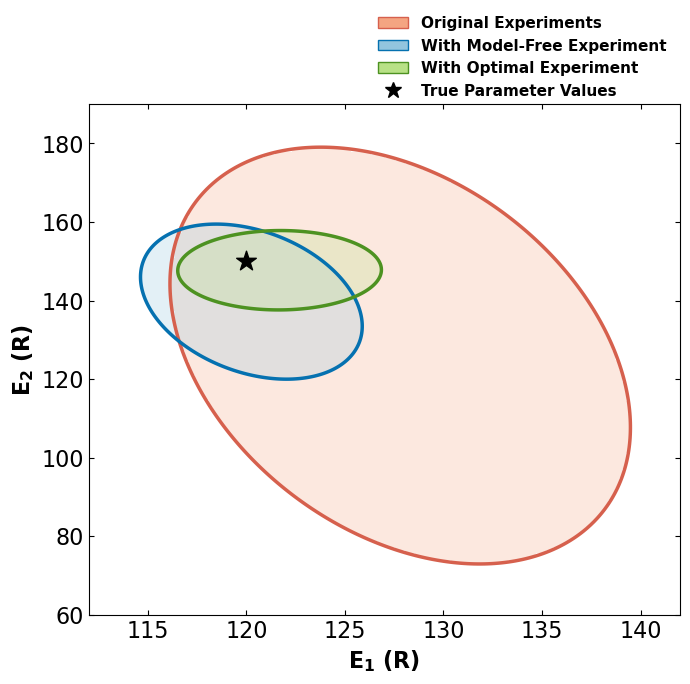

In [52]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                                        param_index=[3, 4],)

plot_confidence_region(cutoff, LR_mat, labels=[r"E$\mathbf{_1}$ (R)", r"E$\mathbf{_2}$ (R)"], 
                      fig_name=["E1", "E2"])

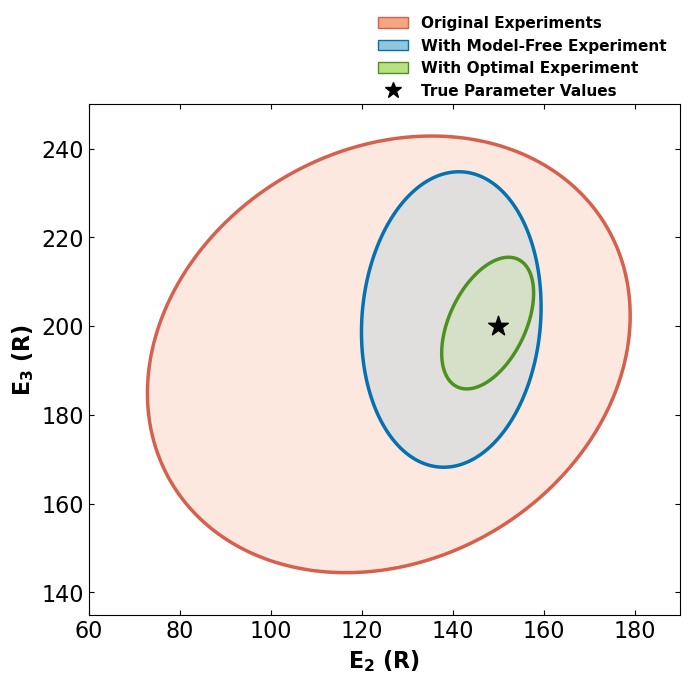

In [53]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                                        param_index=[4, 5],)

plot_confidence_region(cutoff, LR_mat, labels=[r"E$\mathbf{_2}$ (R)", r"E$\mathbf{_3}$ (R)"], 
                      fig_name=["E2", "E3"])

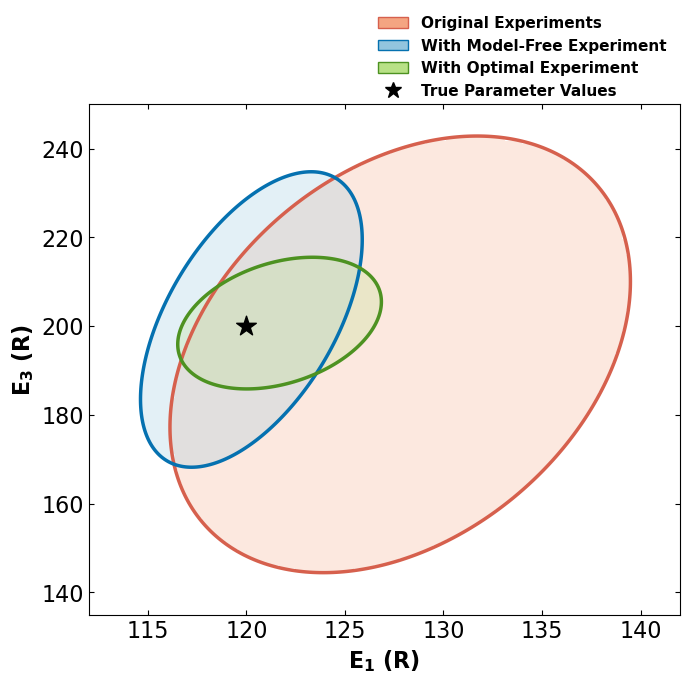

In [54]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                                        param_index=[3, 5],)

plot_confidence_region(cutoff, LR_mat, labels=[r"E$\mathbf{_1}$ (R)", r"E$\mathbf{_3}$ (R)"], 
                      fig_name=["E1", "E3"])

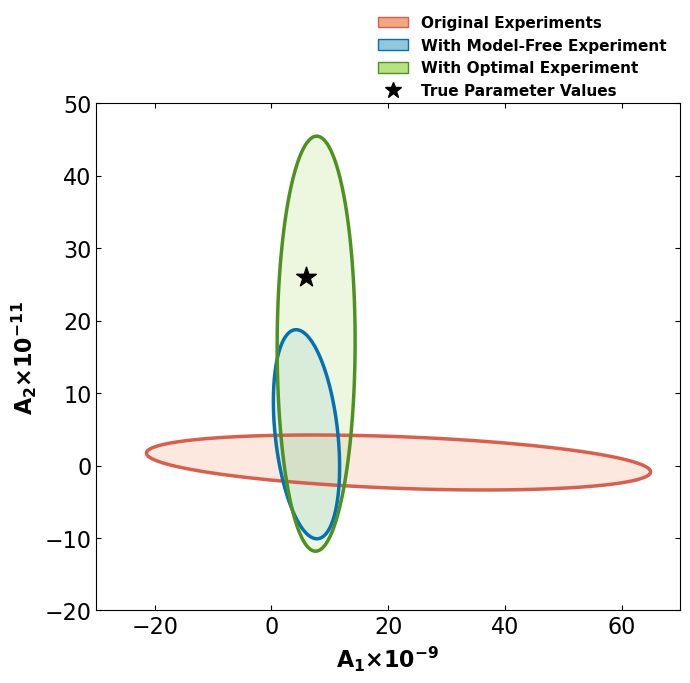

In [55]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                               param_index=[0, 1],)

plot_confidence_region(cutoff, LR_mat, 
                       labels=[r"A$\mathbf{_1}$$\mathbf{\times 10^{-9}}$", 
                               r"A$\mathbf{_2}$$\mathbf{\times 10^{-11}}$"], 
                       fig_name=["a1", "a2"])

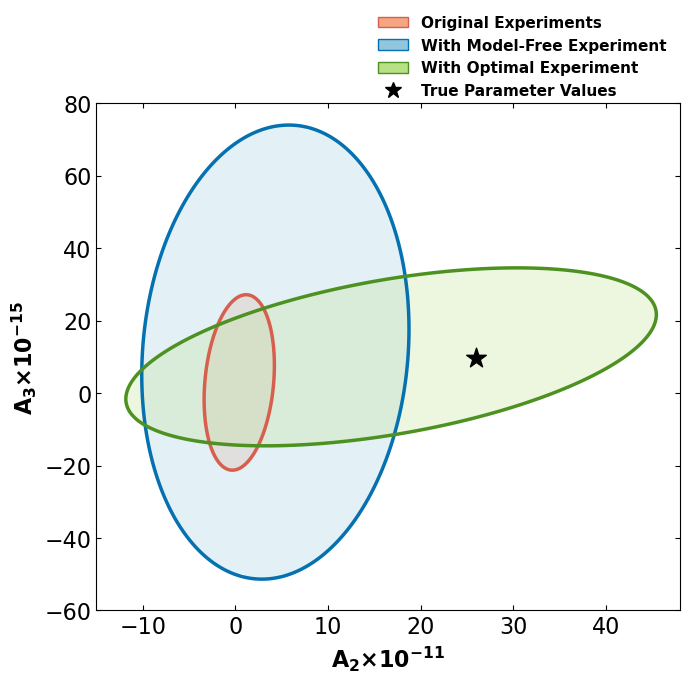

In [56]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                               param_index=[1, 2],)

plot_confidence_region(cutoff, LR_mat, 
                       labels=[r"A$\mathbf{_2}$$\mathbf{\times 10^{-11}}$", 
                               r"A$\mathbf{_3}$$\mathbf{\times 10^{-15}}$"], 
                       fig_name=["a2", "a3"])

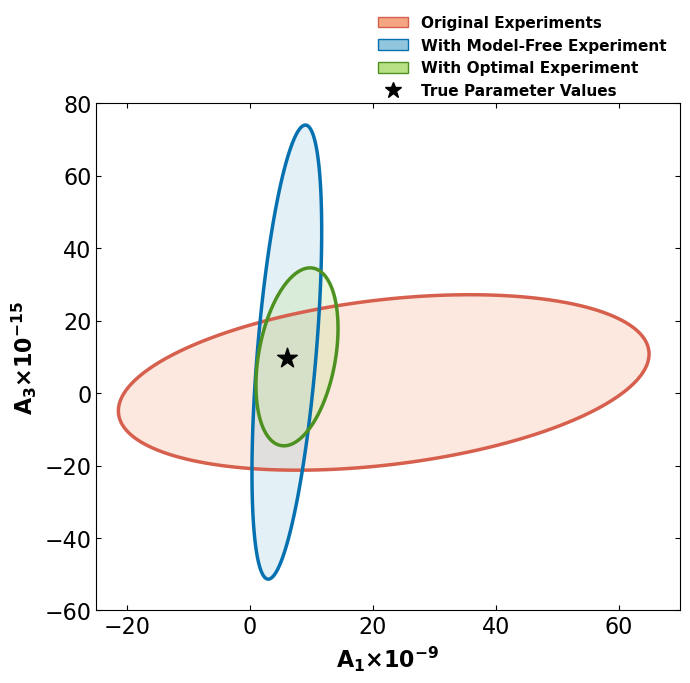

In [57]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                               param_index=[0, 2],)

plot_confidence_region(cutoff, LR_mat, 
                       labels=[r"A$\mathbf{_1}$$\mathbf{\times 10^{-9}}$", 
                               r"A$\mathbf{_3}$$\mathbf{\times 10^{-15}}$"], 
                       fig_name=["a1", "a3"])

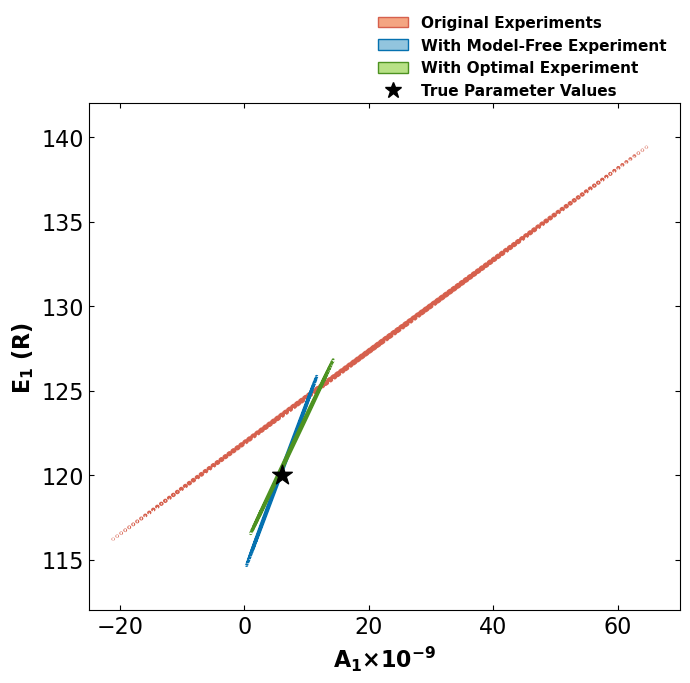

In [58]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                               param_index=[0, 3],)

plot_confidence_region(cutoff, LR_mat, 
                       labels=[r"A$\mathbf{_1}$$\mathbf{\times 10^{-9}}$", 
                               r"E$\mathbf{_1}$ (R)"], 
                       fig_name=["a1", "E1"])

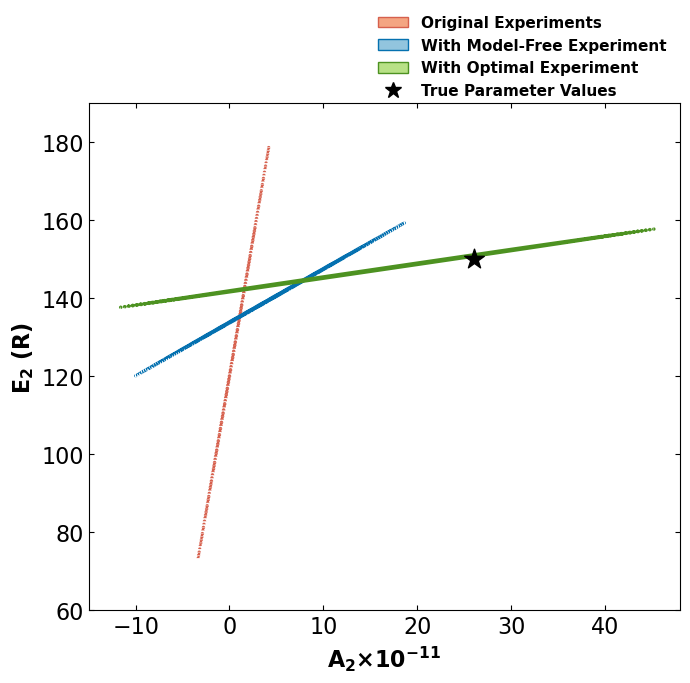

In [59]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                               param_index=[1, 4],)

plot_confidence_region(cutoff, LR_mat, 
                       labels=[r"A$\mathbf{_2}$$\mathbf{\times 10^{-11}}$", 
                               r"E$\mathbf{_2}$ (R)"], 
                       fig_name=["a2", "E2"])

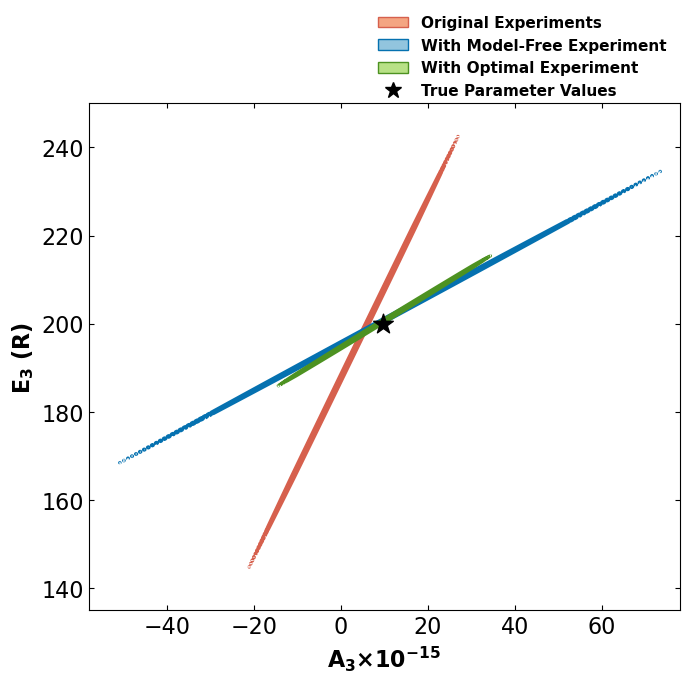

In [60]:
cutoff, LR_mat = likelihood_confidence_ellipse(est_params_det, cov_matrix_det, 
                                               param_index=[2, 5],)

plot_confidence_region(cutoff, LR_mat, 
                       labels=[r"A$\mathbf{_3}$$\mathbf{\times 10^{-15}}$", 
                               r"E$\mathbf{_3}$ (R)"], 
                       fig_name=["a3", "E3"])